In [1]:
NAME = "GROUP 2"
COLLABORATORS = "Craig Vande Ligt, Craig DCosta, Collin Potter-Bonar, Chinonye Ize-Iyamu, Cyrus Estakhri, Colin Steensma"

# INITIAL DATA EXPLORATION

In [3]:
#2023 data exploration:
import requests
import pandas as pd
from io import BytesIO

#2023 GHG emissions url
url = "https://data.ontario.ca/dataset/5e976319-9769-4f77-aab9-d170e0131efe/resource/a2fdbdb2-3cc9-4d30-a60f-58c70f6e3f5a/download/2023_final_data_set.xlsx"

#Set headers to mimic a browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

#Get the file using requests with headers
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise an error if the download failed

#Load the Excel file into a pandas DataFrame
data_2023 = pd.read_excel(BytesIO(response.content), na_values=["Not Available"])

#Display the first few rows of the data
data_2023.info()
data_2023['Primary Property Type - Self Selected'].value_counts().head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9207 entries, 0 to 9206
Data columns (total 58 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   Year                                                           9207 non-null   int64         
 1   Sector                                                         9207 non-null   object        
 2   Subsector                                                      9207 non-null   object        
 3   Organization                                                   9207 non-null   object        
 4   Property Name                                                  9207 non-null   object        
 5   Primary Property Type - Self Selected                          9207 non-null   object        
 6   Portfolio Manager Property ID                                  9207 non-null   int64         
 7

Primary Property Type - Self Selected
Other - Public Services                    2105
Fire Station                                752
Social/Meeting Hall                         704
Office                                      675
Wastewater Treatment Plant                  642
Drinking Water Treatment & Distribution     636
Other                                       428
Library                                     398
College/University                          353
Indoor Arena                                267
Ice/Curling Rink                            257
Other - Recreation                          231
Other - Lodging/Residential                 211
Transportation Terminal/Station             186
Single-Family Home                          175
Parking                                     167
Police Station                              152
Hospital (General Medical & Surgical)       129
Other - Entertainment/Public Assembly       108
Museum                                       77
Na

# START OF DATA PREPROCESSING

## Web scraping from Ontario government open data website

In [6]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from io import BytesIO


#Perform webscraping to get years and urls of excel GHG emissions files
base_url = "https://data.ontario.ca/dataset/energy-use-and-greenhouse-gas-emissions-for-the-broader-public-sector"
# Set headers to mimic a browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(base_url, headers=headers)
response.raise_for_status()

full_urls = []
soup = BeautifulSoup(response.text, 'html.parser')
li_soup = soup.find_all('li', {'class':'resource-item ontario-row resource-item-div'})
for rss in li_soup:
    if rss.find_all('span', {'class':'label label-english'}):
        for year in rss.find('span', {'class': 'resource-item-title'}):
            year = year.split(" ")[0] #Get the year
            if year.isdigit(): #Check if year string is a number
                if int(year) >= 2011: #Hardset data that can be changed as chosen by user
                    links = rss.find_all('a', href=True)
                    for link in links:
                        url = link['href']
                        full_url = ('https://data.ontario.ca/' + url + '/download/{}_final_data_set.xlsx'.format(year))
                        full_urls.append((int(year), full_url)) #appending tuples of year and url for the given year to the list full_urls\

for year, url in full_urls:
    print("YEAR:", year, "   URL:", url)

YEAR: 2023    URL: https://data.ontario.ca//dataset/energy-use-and-greenhouse-gas-emissions-for-the-broader-public-sector/resource/a2fdbdb2-3cc9-4d30-a60f-58c70f6e3f5a/download/2023_final_data_set.xlsx
YEAR: 2022    URL: https://data.ontario.ca//dataset/energy-use-and-greenhouse-gas-emissions-for-the-broader-public-sector/resource/88c3efde-5bd5-4645-811d-ef1ffe3d05cc/download/2022_final_data_set.xlsx
YEAR: 2021    URL: https://data.ontario.ca//dataset/energy-use-and-greenhouse-gas-emissions-for-the-broader-public-sector/resource/4727e0fb-d020-4ea8-b27a-20f383d05199/download/2021_final_data_set.xlsx
YEAR: 2020    URL: https://data.ontario.ca//dataset/energy-use-and-greenhouse-gas-emissions-for-the-broader-public-sector/resource/af9bef69-01de-4979-a62e-78ecbd215a01/download/2020_final_data_set.xlsx
YEAR: 2019    URL: https://data.ontario.ca//dataset/energy-use-and-greenhouse-gas-emissions-for-the-broader-public-sector/resource/054263bd-9d22-4fd5-9057-333b0bf97df1/download/2019_final_data

In [7]:
#Get data via urls, create year column, and place datasets into a list called datasets
col_dict = {2011: ['Sector Name', 'SubSector Name', 'Organization Name', 'Operation Name', 'Operation Type', 'City', 'Postal Code', 'Total Floor Area', 'Unit1', 'Average Hours Per Week', 'GHG Emissions(Kg)', 'Energy Intensity GJ_m2'],
           2012: ['Sector Name', 'Sub Sector ', 'Organization Name', 'Operation Name', 'Operation Type', 'City', 'Postal Code', 'Total Floor Area ', 'Unit', 'Average Hours per week', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2013: ['Sector', 'Sub Sector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2014: ['Sector', 'Sub Sector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2015: ['Sector', 'SubSector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2016: ['Sector', 'Sub Sector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2017: ['Sector', 'SubSector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2018: ['Sector', 'SubSector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2019: ['Sector', 'SubSector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2020: ['Sector', 'SubSector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Total Indoor Space_x', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions KG', 'Energy Intensity GJ_m2'],
           2021: ['Sector', 'Subsector', 'Organization', 'Property Name', 'Primary Property Type - Self Selected', 'City', 'Postal Code', 'Property GFA - Self-Reported (m²)', 'Custom Property ID 2 - Name', 'Custom Property ID 2 - Value', 'Custom Property ID 3 - Name', 'Custom Property ID 3 - Value', 'Source EUI (GJ/m²)', 'Total (Location-Based) GHG Emissions (Metric Tons CO2e)', 'Total (Location-Based) GHG Emissions Intensity (kgCO2e/m²)'],
           2022: ['Sector', 'Subsector', 'Organization', 'Property Name', 'Primary Property Type - Self Selected', 'City', 'Postal Code', 'Property GFA - Self-Reported (m²)', 'Custom Property ID 2 - Name', 'Custom Property ID 2 - Value', 'Custom Property ID 3 - Name', 'Custom Property ID 3 - Value', 'Source EUI (GJ/m²)', 'Total (Location-Based) GHG Emissions (Metric Tons CO2e)', 'Total (Location-Based) GHG Emissions Intensity (kgCO2e/m²)'],
           2023: ['Sector', 'Subsector', 'Organization', 'Property Name', 'Primary Property Type - Self Selected', 'City', 'Postal Code', 'Property GFA - Self-Reported (m²)', 'Custom Property ID 2 - Name', 'Custom Property ID 2 - Value', 'Custom Property ID 3 - Name', 'Custom Property ID 3 - Value', 'Source EUI (GJ/m²)', 'Total (Location-Based) GHG Emissions (Metric Tons CO2e)', 'Total (Location-Based) GHG Emissions Intensity (kgCO2e/m²)']
          }
col_names_pre2021 = ['Sector', 'Subsector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Property GFA (m²)', 'Unit of Measure', 'Weekly Average Hours', 'GHG Emissions (Kg)', 'Energy Intensity (GJ/m²)']
col_names_post2020 = ['Sector', 'Subsector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Property GFA (m²)', 'Custom Property ID 2 - Name', 'Custom Property ID 2 - Value', 'Custom Property ID 3 - Name', 'Custom Property ID 3 - Value', 'Source EUI (GJ/m²)', 'GCG Emissions (1000 KG CO2e)', 'GHG Emissions Intensity (kgCO2e/m²)']

datasets = []
for year, url in full_urls:
    if year <= 2020:
        print(year)
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an error if the download failed

        # Load the Excel file into a pandas DataFrame and add a 'Year' column
        if year <= 2015:
            dataset = pd.read_excel(BytesIO(response.content), usecols=col_dict[year], skiprows=[0,1], na_values=["Not Available"])
            rename_dict = dict(zip(col_dict[year],col_names_pre2021))
            dataset = dataset.rename(columns=rename_dict)
            dataset['Year'] = year
            datasets.append(dataset)
        else:
            dataset = pd.read_excel(BytesIO(response.content), usecols=col_dict[year], na_values=["Not Available"])
            rename_dict = dict(zip(col_dict[year],col_names_pre2021))
            dataset = dataset.rename(columns=rename_dict)
            dataset['Year'] = year
            datasets.append(dataset)
    else:
        print(year)
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an error if the download failed

        dataset = pd.read_excel(BytesIO(response.content), usecols=col_dict[year], na_values=["Not Available"])
        rename_dict = dict(zip(col_dict[year],col_names_post2020))
        dataset = dataset.rename(columns=rename_dict)
        dataset['Year'] = year
        datasets.append(dataset)

#Concat datsets list to become ontario_emissions_df from which cleaning can begin
#ontario_emissions_df_pre2021 = pd.concat(datasets, ignore_index=True)
datasets_backup = datasets.copy()

2023
2022
2021
2020
2019
2018
2017
2016
2015
2014
2013
2012
2011


## Combining of annual datasets: 2011-2023

In [9]:
#Pre-clean 2011 - 2020 data
datasets_2011thru2020 = datasets_backup[3:].copy()

for ds in datasets_2011thru2020:
    ds.rename(columns={'Energy Intensity (GJ/m²)': 'Source EUI (GJ/m²)'}, inplace=True)

    ds['GHG Emissions (Kg)'] = ds['GHG Emissions (Kg)']/1000
    ds.rename(columns={'GHG Emissions (Kg)': 'GHG Emissions (1000 KG CO2e)'}, inplace=True)

    ds.loc[ds['Unit of Measure'] == 'Square feet', 'Property GFA (m²)'] = ds['Property GFA (m²)'] * 0.092903
    ds.drop('Unit of Measure', axis=1, inplace=True)
    ds.loc[ds['Property GFA (m²)'] > 0, 'GHG Emissions Intensity (kgCO2e/m²)'] = (1000 * ds['GHG Emissions (1000 KG CO2e)'])/ds['Property GFA (m²)']

#datasets_2011thru2020[0]

In [10]:
#pre-clean 2021 - 2023 data
datasets_2021thru2023 = datasets[:3].copy()
for ds in datasets_2021thru2023:
    ds.loc[ds['Custom Property ID 2 - Name'].str.contains('Weekly Average Hours', na=False), 'Weekly Average Hours'] = ds['Custom Property ID 2 - Value']
    ds.loc[ds['Custom Property ID 3 - Name'].str.contains('Weekly Average Hours', na=False), 'Weekly Average Hours'] = ds['Custom Property ID 3 - Value']
    ds.drop(['Custom Property ID 2 - Name', 'Custom Property ID 2 - Value', 'Custom Property ID 3 - Name', 'Custom Property ID 3 - Value'], axis=1, inplace=True)
    ds.rename(columns={'GCG Emissions (1000 KG CO2e)':'GHG Emissions (1000 KG CO2e)'}, inplace=True)
#datasets_2021thru2023[0]

In [11]:
#Concatenate data together
ontario_emissions_df_2011thru2020 = pd.concat(datasets_2011thru2020, ignore_index=True)
ontario_emissions_df_2021thru2023 = pd.concat(datasets_2021thru2023, ignore_index=True)
ontario_emissions_df = pd.concat([ontario_emissions_df_2011thru2020, ontario_emissions_df_2021thru2023], ignore_index=True)

#Adjust order of DF columns
ontario_emissions_df = ontario_emissions_df[['Year', 'Sector', 'Subsector', 'Organization', 'Operation', 'Operation Type', 'City', 'Postal Code', 'Property GFA (m²)', 'Weekly Average Hours', 'Source EUI (GJ/m²)', 'GHG Emissions (1000 KG CO2e)', 'GHG Emissions Intensity (kgCO2e/m²)']]
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212271 entries, 0 to 212270
Data columns (total 13 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Year                                 212271 non-null  int64  
 1   Sector                               212271 non-null  object 
 2   Subsector                            212266 non-null  object 
 3   Organization                         212271 non-null  object 
 4   Operation                            212271 non-null  object 
 5   Operation Type                       212271 non-null  object 
 6   City                                 212270 non-null  object 
 7   Postal Code                          212080 non-null  object 
 8   Property GFA (m²)                    209166 non-null  float64
 9   Weekly Average Hours                 201188 non-null  object 
 10  Source EUI (GJ/m²)                   198881 non-null  float64
 11  GHG Emissions

In [12]:
#ontario_emissions_df = ontario_emissions_df.dropna()
ontario_emissions_df.groupby('Year')['GHG Emissions (1000 KG CO2e)'].describe()

#Note negative values are indicative of renewable energy usage instead of GHG.

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,18743.0,481.216365,3.986370e+04,0.000000e+00,7.226919,34.688709,111.286843,5.452489e+06
2012,17978.0,213.216851,1.846825e+03,9.604000e-10,7.047280,35.407144,119.872019,1.049984e+05
2013,17010.0,73225.727001,3.538278e+06,0.000000e+00,7.587977,39.532863,128.907892,2.801573e+08
2014,17224.0,170.467496,1.307981e+03,0.000000e+00,6.266098,35.825249,113.522017,9.966540e+04
2015,17663.0,156.375421,1.291391e+03,0.000000e+00,5.262653,30.571111,97.572883,9.944464e+04
2016,17564.0,150.291802,1.232913e+03,0.000000e+00,4.504160,27.346916,93.419385,9.277838e+04
2017,16949.0,149.138196,1.208140e+03,0.000000e+00,3.437566,27.169673,95.843699,8.723532e+04
2018,16620.0,162.399722,1.337187e+03,0.000000e+00,5.116471,33.296897,106.929209,8.760936e+04
2019,17208.0,735.237909,5.874668e+04,0.000000e+00,4.651013,31.387946,96.868801,7.217241e+06


## Data Cleaning
Note that the data has been looked through thoroughly and this is the cleanest way to put the code together without all the small checks for no data values and more. We began by removing some small inconsistencies in the data, such as 'yes' values in column of float values, removal of 2 full rows of NA values, and the conversion of the year column back into integer 64-bit formatting. Following this, inconsistent naming in various columns is fixed (at minimum for larger counts of the given strings) to help normalize the naming convensions used. Average data was used to fill in the missing data for `Weekly Average Hours`.

In [14]:
#Remove 'Yes' from hours column
ontario_emissions_df.loc[ontario_emissions_df['Weekly Average Hours'] == 'Yes', 'Weekly Average Hours'] = pd.NA

#Drop 2 NA rows from dataset
ontario_emissions_df[ontario_emissions_df['Year'].isnull()==True].head() # reveals 2 NA rows...these will be dropped
ontario_emissions_df = ontario_emissions_df.dropna(subset=['Year'])

#Convert Year column to integer column
ontario_emissions_df['Year'] = ontario_emissions_df['Year'].astype(np.int64)

#Create backup copy of dataset in case something goes wrong
ontario_emissions_df_raw = ontario_emissions_df.copy()
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212271 entries, 0 to 212270
Data columns (total 13 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Year                                 212271 non-null  int64  
 1   Sector                               212271 non-null  object 
 2   Subsector                            212266 non-null  object 
 3   Organization                         212271 non-null  object 
 4   Operation                            212271 non-null  object 
 5   Operation Type                       212271 non-null  object 
 6   City                                 212270 non-null  object 
 7   Postal Code                          212080 non-null  object 
 8   Property GFA (m²)                    209166 non-null  float64
 9   Weekly Average Hours                 201188 non-null  object 
 10  Source EUI (GJ/m²)                   198881 non-null  float64
 11  GHG Emissions

In [15]:
#Convert data to numeric from string
ontario_emissions_df['Weekly Average Hours'] = pd.to_numeric(ontario_emissions_df['Weekly Average Hours'], errors='coerce')


### Cleaning of Operation Type, Sector and Subsector columns

In [17]:

#Normalize Sector and other column data to lowercase for simplifying and combining data
ontario_emissions_df['Sector'] = ontario_emissions_df['Sector'].str.lower()
ontario_emissions_df['Operation Type'] = ontario_emissions_df['Operation Type'].str.lower()
ontario_emissions_df['Subsector'] = ontario_emissions_df['Subsector'].str.lower()


In [18]:
#Translating French Operation Type values into English
translation_dict = {
    'installations utilisées pour des besoins hospitaliers': 'facilities used for hospital purposes',
    'école': 'school',
    'stationnement intérieur': 'parking garage',
    'installations de loisir intérieures': 'indoor recreational facilities',
    'centres communautaires': 'community centres',
    'musée': 'museum',
    'patinoires intérieures': 'indoor ice rinks',
    'postes d\'incendie et bureaux et installations connexes': 'fire station and associated offices and facilities',
    'installations liées au traitement de l\'eau': 'facilities related to the treatment of water',
    'installations liées au pompage des eaux usées': 'facilities related to the pumping of sewage',
    'installations liées au traitement des eaux usées': 'facilities related to the treatment of sewage',
    'bureau': 'office',
    'salle sociale/de réunion': 'social/meeting hall',
    'hôpital (médical général et chirurgical)': 'hospital (general medical & surgical)',
    'laboratoire': 'laboratory',
    'communauté de vie pour personnes âgées': 'senior living community',
    'bureau vétérinaire': 'veterinary office',
    'centre de congrès': 'convention center',
    'piscine intérieure': 'indoor swimming pool',
    'centre de conditionnement physique/salle de sport': 'fitness center/health club/gym',
    'centre de loisirs': 'recreational facility',
    'centre d\'éducation des adultes': 'adult education',
    'magasin de proximité sans station-service': 'convenience store without gas station',
    'autre - services': 'other - services',
    'autre - éducation': 'other - education',
    'autre - logement/résidentiel': 'other - lodging/residential',
    'autre - restaurant/bar': 'other - restaurant/bar',
    'autre - divertissement/assemblée publique': 'other - entertainment/public assembly',
    'autre - hôpital spécialisé': 'other - specialty hospital',
    'autre - soins ambulatoires/thérapie physique': 'outpatient rehabilitation/physical therapy',
    'autre - technologie/science': 'other - technology/science',
    'autre - services publics': 'other - public services',
    'autre - stade': 'other - stadium',
    'stade (fermé)': 'stadium (closed)',
    'stade (ouvert)': 'stadium (open)',
    'réparation de services (véhicule, chaussure, serrurier, etc.)': 'repair services (vehicle, shoe, locksmith, etc.)',
    'autre - loisirs': 'other - recreation',
    'autre - vente de nourriture': 'other - food sales',
    'maison unifamiliale': 'single-family home',
    'logement multifamilial': 'multifamily housing',
    'installations de stockage': 'self-storage facility',
    'installations de traitement et de distribution d\'eau potable': 'drinking water treatment & distribution',
    'station de traitement des eaux usées': 'wastewater treatment plant',
    'usine de fabrication/industrielle': 'manufacturing/industrial plant',
    'terminal/station de transport': 'transportation terminal/station',
    'autre - services publics': 'other - utility',
    'autre - soins urgents/clinique/autre ambulatoire': 'urgent care/clinic/other outpatient',
    'autre - services de restauration': 'other - food service',
    'autre - arts de la scène': 'other - performing arts',
    'autre - aréna intérieure': 'other - indoor arena',
    'autre - installation de stockage': 'other - storage',
    'autre - installation culturelle': 'other - cultural facilities',
    'autre - installation de loisirs': 'other - recreation facilities',
    'autre - installation de traitement des eaux': 'other - facilities related to the treatment of water',
    "installations d'entreposage où le matériel et les véhicules sont entretenus, réparés ou entreposés" : 'warehousing facilities where equipment and vehicles are maintained, repaired or stored',
}

def translate(df, column_name, translation_dict):
    df[column_name] = df[column_name].replace(translation_dict)
    return df

ontario_emissions_df = translate(ontario_emissions_df, 'Operation Type', translation_dict)

In [19]:
#Note: Data cleaning for Operations Type was done by using multiple runs/checks with
#    diferent names in ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('<name>'), 'Operation Type'].value_counts().head(50)

#clean data by converting all 'school' containing names to 'school' for Operation Type
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('school'),'Operation Type'] = 'school'
#clean up some of the operation type data in a similar manner
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('admin|adin'), 'Operation Type'] = 'administrative'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('fire station|firestation|fire hall'), 'Operation Type'] = 'fire station and associated offices and facilities'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('police'), 'Operation Type'] = 'police stations and associated offices and facilities'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('gym'), 'Operation Type'] = 'fitness center/health club/gym'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('librar'), 'Operation Type'] = 'library'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('laborator'), 'Operation Type'] = 'laboratories'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('restaurant'), 'Operation Type'] = 'restaurant/bar'
ontario_emissions_df.loc[ontario_emissions_df['Operation Type'].str.contains('indoor recreational facili'), 'Operation Type'] = 'indoor recreational facilities'

#clean up sector data in a similar manner
ontario_emissions_df.loc[ontario_emissions_df['Sector'].str.contains('school board'), 'Sector'] = 'school board'
ontario_emissions_df.loc[ontario_emissions_df['Sector'].str.contains('post-secondary|postsecondary'), 'Sector'] = 'post-secondary'
ontario_emissions_df.loc[ontario_emissions_df['Sector'].str.contains('municipal'), 'Sector'] = 'municipal'

#clean up subsector in a similar manner
ontario_emissions_df.loc[(ontario_emissions_df['Subsector'].isnull() & ontario_emissions_df['Organization'].str.contains('College')), 'Subsector'] = 'college'
ontario_emissions_df.loc[ontario_emissions_df['Subsector'].str.contains('universit', na=False), 'Subsector'] = 'university'

In [20]:
#Isolate all rows with the Operation Type "Other" and review to understand what's in it
type_other = ontario_emissions_df[ontario_emissions_df['Operation Type'] == 'other']
list_other = type_other['Operation'].tolist()
type_other['Operation'].value_counts()

#Begin preparation for engineered field, Operation Sector
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r' Park|Garden|Playground|Parkette',case=False,na=False), 'Operation Type'] = 'other - parks'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Pump Station|Pumping Station|Pumpstation|Pump House',case=False,na=False), 'Operation Type'] = 'industrial - pumps'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Water Treatment|Water Tower|Water Plant',case=False,na=False), 'Operation Type'] = 'industrial - water'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Sewer|Sewage|Recycling',case=False,na=False), 'Operation Type'] = 'industrial - waste'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Pool|Swimming',case=False,na=False), 'Operation Type'] = 'other - pools'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Streetlight|Street Light|Traffic Light',case=False,na=False), 'Operation Type'] = 'other - streetlights'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Landfill',case=False,na=False), 'Operation Type'] = 'other - landfills'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Subway|Transit',case=False,na=False), 'Operation Type'] = 'industrial - transit'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Medical|Health|Emergency|Hospital',case=False,na=False), 'Operation Type'] = 'medical'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Residence|Apartment|Condo|LHC|Manor|Estate|Home|Housing',case=False,na=False), 'Operation Type'] = 'other - residential'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'School|Childcare|Child Care|Daycare|Day Care',case=False,na=False), 'Operation Type'] = 'school'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Tele|Communication|Transfer Station|Utilities|Heat Tracing',case=False,na=False), 'Operation Type'] = 'industrial - utilities'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Centre|Community|Washroom|Food Bank|Market|Clubhouse|Shop|Rink',case=False,na=False), 'Operation Type'] = 'commercial'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Parking',case=False,na=False), 'Operation Type'] = 'other - parking'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Office',case=False,na=False), 'Operation Type'] = 'administrative'
ontario_emissions_df.loc[ontario_emissions_df['Operation'].str.contains(r'Airport',case=False,na=False), 'Operation Type'] = 'airports'
ontario_emissions_df.loc[ontario_emissions_df['Subsector'].str.contains(r'school board',case=False,na=False), 'Operation Type'] = 'administrative'
ontario_emissions_df.loc[ontario_emissions_df['Subsector'].str.contains(r'college',case=False,na=False), 'Operation Type'] = 'school'

### Imputing missing values

In [22]:
#Find missing values for 'Property GFA (m²)' based on year.
#Infer these values from GHG Emissions / GHG Emissions Intensity
mask = ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)'] > 0

ontario_emissions_df.loc[mask, 'Property GFA (m²)'] = ontario_emissions_df.loc[mask, 'Property GFA (m²)'].fillna(
    (ontario_emissions_df.loc[mask, 'GHG Emissions (1000 KG CO2e)'] * 1000) / ontario_emissions_df.loc[mask, 'GHG Emissions Intensity (kgCO2e/m²)']
)

In [23]:
ontario_emissions_df[ontario_emissions_df['Property GFA (m²)'].isnull()]['Year'].value_counts()#['Source EUI (GJ/m²)'].value_counts()
ontario_emissions_df.info()
ontario_emissions_df.groupby('Year')['GHG Emissions (1000 KG CO2e)'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212271 entries, 0 to 212270
Data columns (total 13 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Year                                 212271 non-null  int64  
 1   Sector                               212271 non-null  object 
 2   Subsector                            212271 non-null  object 
 3   Organization                         212271 non-null  object 
 4   Operation                            212271 non-null  object 
 5   Operation Type                       212271 non-null  object 
 6   City                                 212270 non-null  object 
 7   Postal Code                          212080 non-null  object 
 8   Property GFA (m²)                    209166 non-null  float64
 9   Weekly Average Hours                 201185 non-null  float64
 10  Source EUI (GJ/m²)                   198881 non-null  float64
 11  GHG Emissions

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,18743.0,481.216365,3.986370e+04,0.000000e+00,7.226919,34.688709,111.286843,5.452489e+06
2012,17978.0,213.216851,1.846825e+03,9.604000e-10,7.047280,35.407144,119.872019,1.049984e+05
2013,17010.0,73225.727001,3.538278e+06,0.000000e+00,7.587977,39.532863,128.907892,2.801573e+08
2014,17224.0,170.467496,1.307981e+03,0.000000e+00,6.266098,35.825249,113.522017,9.966540e+04
2015,17663.0,156.375421,1.291391e+03,0.000000e+00,5.262653,30.571111,97.572883,9.944464e+04
2016,17564.0,150.291802,1.232913e+03,0.000000e+00,4.504160,27.346916,93.419385,9.277838e+04
2017,16949.0,149.138196,1.208140e+03,0.000000e+00,3.437566,27.169673,95.843699,8.723532e+04
2018,16620.0,162.399722,1.337187e+03,0.000000e+00,5.116471,33.296897,106.929209,8.760936e+04
2019,17208.0,735.237909,5.874668e+04,0.000000e+00,4.651013,31.387946,96.868801,7.217241e+06


In [24]:
#Impute NA values by Operation Type mean value by year
operation_grouped_hours_means = ontario_emissions_df.groupby(['Operation Type', 'Year'])['Weekly Average Hours'].transform('mean')
ontario_emissions_df['Weekly Average Hours'] = ontario_emissions_df['Weekly Average Hours'].fillna(operation_grouped_hours_means)
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212271 entries, 0 to 212270
Data columns (total 13 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Year                                 212271 non-null  int64  
 1   Sector                               212271 non-null  object 
 2   Subsector                            212271 non-null  object 
 3   Organization                         212271 non-null  object 
 4   Operation                            212271 non-null  object 
 5   Operation Type                       212271 non-null  object 
 6   City                                 212270 non-null  object 
 7   Postal Code                          212080 non-null  object 
 8   Property GFA (m²)                    209166 non-null  float64
 9   Weekly Average Hours                 212215 non-null  float64
 10  Source EUI (GJ/m²)                   198881 non-null  float64
 11  GHG Emissions

In [25]:
#ontario_emissions_df['Sector'].value_counts().head(50)
# ontario_emissions_df['Operation Type'].value_counts().head(50)
# ontario_emissions_df[ontario_emissions_df['Weekly Average Hours'].isnull()==True]
print(ontario_emissions_df[ontario_emissions_df['Weekly Average Hours'].isnull()==True]['Year'].count()) #dropping 56 values

#Note that no other same named data for the given year was found to properly fill in the
#    rest of the NAs. Since this is the case and there is minimal data loss, we are going
#    to drop the NA data.
ontario_emissions_df = ontario_emissions_df.dropna(subset=['Weekly Average Hours'])
ontario_emissions_df.info()

56
<class 'pandas.core.frame.DataFrame'>
Index: 212215 entries, 0 to 212270
Data columns (total 13 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Year                                 212215 non-null  int64  
 1   Sector                               212215 non-null  object 
 2   Subsector                            212215 non-null  object 
 3   Organization                         212215 non-null  object 
 4   Operation                            212215 non-null  object 
 5   Operation Type                       212215 non-null  object 
 6   City                                 212214 non-null  object 
 7   Postal Code                          212024 non-null  object 
 8   Property GFA (m²)                    209110 non-null  float64
 9   Weekly Average Hours                 212215 non-null  float64
 10  Source EUI (GJ/m²)                   198828 non-null  float64
 11  GHG Emissions (

In [26]:
#Impute Emissions, Emissions Intensity, and Property GFA where ever possible using the other 2 when non-zero
ontario_emissions_df.loc[(ontario_emissions_df['GHG Emissions (1000 KG CO2e)'].isnull()) & (ontario_emissions_df['Property GFA (m²)'] >= 0), 'GHG Emissions (1000 KG CO2e)'] = (ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)'] / 1000) * ontario_emissions_df['Property GFA (m²)']
ontario_emissions_df.loc[(ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)'].isnull()) & (ontario_emissions_df['Property GFA (m²)'] > 0), 'GHG Emissions Intensity (kgCO2e/m²)'] = (ontario_emissions_df['GHG Emissions (1000 KG CO2e)'] * 1000) / ontario_emissions_df['Property GFA (m²)']
ontario_emissions_df.loc[(ontario_emissions_df['Property GFA (m²)'].isnull()) & (ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)'] > 0 ), 'Property GFA (m²)'] = (ontario_emissions_df['GHG Emissions (1000 KG CO2e)'] * 1000) / ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)']
ontario_emissions_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 212215 entries, 0 to 212270
Data columns (total 13 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Year                                 212215 non-null  int64  
 1   Sector                               212215 non-null  object 
 2   Subsector                            212215 non-null  object 
 3   Organization                         212215 non-null  object 
 4   Operation                            212215 non-null  object 
 5   Operation Type                       212215 non-null  object 
 6   City                                 212214 non-null  object 
 7   Postal Code                          212024 non-null  object 
 8   Property GFA (m²)                    209110 non-null  float64
 9   Weekly Average Hours                 212215 non-null  float64
 10  Source EUI (GJ/m²)                   198828 non-null  float64
 11  GHG Emissions (100

In [27]:
#Impute GHG Emissions Intensity (kgCO2e/m²) values where GHG Emissions == 0
ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)'] = ontario_emissions_df.loc[(pd.isnull(ontario_emissions_df['GHG Emissions Intensity (kgCO2e/m²)']) & ontario_emissions_df['GHG Emissions (1000 KG CO2e)'] == 0), 'GHG Emissions (1000 KG CO2e)']



### Create normalized GHG emissions intensity attribute

In [29]:

#Create Normalized GHG Emissions Intensity attribute
ontario_emissions_df['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] = np.nan #fill with NaNs

#Using a value of 1 since most small values (0, 0.00001, etc) do not exist in reality
ontario_emissions_df.loc[(ontario_emissions_df['Property GFA (m²)'] > 1), 'GHG Emissions Intensity Recalculated (kgCO2e/m²)'] = (ontario_emissions_df['GHG Emissions (1000 KG CO2e)'] * 1000) / ontario_emissions_df['Property GFA (m²)']

#Note that since a lot of the industrial processes contain 0 Property GFA, we cannot compute the Normalized value
#    without significant error being introduced. For this reason, they will be left as NaN values for now.
ontario_emissions_df.loc[(ontario_emissions_df['Weekly Average Hours'] > 0), 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] = ontario_emissions_df['GHG Emissions Intensity Recalculated (kgCO2e/m²)']/ontario_emissions_df['Weekly Average Hours']

# #fill na with 0 where places are closed == 0
ontario_emissions_df.loc[ontario_emissions_df['Weekly Average Hours'] == 0, 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] = 0

ontario_emissions_df[ontario_emissions_df['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].isnull()].head()
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212215 entries, 0 to 212270
Data columns (total 15 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              212215 non-null  int64  
 1   Sector                                            212215 non-null  object 
 2   Subsector                                         212215 non-null  object 
 3   Organization                                      212215 non-null  object 
 4   Operation                                         212215 non-null  object 
 5   Operation Type                                    212215 non-null  object 
 6   City                                              212214 non-null  object 
 7   Postal Code                                       212024 non-null  object 
 8   Property GFA (m²)                                 209110 non-null  float64
 9   Weekly Av

In [30]:
#dropping duplicates
ontario_emissions_df = ontario_emissions_df.drop_duplicates()
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212119 entries, 0 to 212270
Data columns (total 15 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              212119 non-null  int64  
 1   Sector                                            212119 non-null  object 
 2   Subsector                                         212119 non-null  object 
 3   Organization                                      212119 non-null  object 
 4   Operation                                         212119 non-null  object 
 5   Operation Type                                    212119 non-null  object 
 6   City                                              212118 non-null  object 
 7   Postal Code                                       211928 non-null  object 
 8   Property GFA (m²)                                 209023 non-null  float64
 9   Weekly Av

In [31]:
ontario_emissions_df.duplicated().value_counts()

False    212119
Name: count, dtype: int64

### Create operation types attribute

In [33]:
#Create dictionary to get Operation Type by Sector
operations_sector_dict = {
    'school': 'schools',
    'administrative': 'offices',
    'fire station and associated offices and facilities': 'medical',
    'storage facilities where equipment or vehicles are maintained, repaired or stored': 'industrial',
    'other': 'undecided',
    'community centres': 'commercial',
    'library': 'commercial',
    'facilities related to the pumping of sewage': 'industrial',
    'facilities related to the pumping of water': 'industrial',
    'cultural facilities': 'commercial',
    'other - public services': 'commercial',
    'facilities related to the treatment of water': 'industrial',
    'indoor ice rinks': 'commercial',
    'indoor recreational facilities': 'commercial',
    'facilities related to the treatment of sewage': 'industrial',
    'ambulance stations and associated offices and facilities': 'medical',
    'facilities used for hospital purposes': 'medical',
    'classrooms and related facilities': 'schools',
    'police stations and associated offices and facilities': 'medical',
    'office': 'offices',
    'social/meeting hall': 'commercial',
    'laboratories': 'industrial',
    'drinking water treatment & distribution': 'industrial',
    'wastewater treatment plant': 'industrial',
    'parking garages': 'commercial',
    'street lighting': 'industrial',
    'indoor swimming pools': 'commercial',
    'indoor sports arenas': 'commercial',
    'college/university': 'schools',
    'indoor arena': 'commercial',
    'student residences': 'residential',
    'ice/curling rink': 'commercial',
    'fitness center/health club/gym': 'commercial',
    'other - lodging/residential': 'residential',
    'other - recreation': 'commercial',
    'social housing': 'residential',
    'single-family home': 'residential',
    'student recreational facilities and athletic facilities': 'schools',
    'performing arts facilities': 'commercial',
    'hospital (general medical & surgical)': 'medical',
    'art galleries': 'commercial',
    'other - entertainment/public assembly': 'commercial',
    'long-term care': 'residential',
    'museum': 'commercial',
    'other - utility': 'industrial',
    'auditoriums': 'commercial',
    'multifamily housing': 'residential',
    'medical office': 'medical',
    'residence hall/dormitory': 'residential',
    'parking': 'commercial',
    'performing arts': 'commercial',
    'senior living community': 'residential',
    'residential care facility': 'residential',
    'stadium (closed)': 'commercial',
    'parking garage': 'commercial',
    'heated swimming pool': 'commercial',
    'transportation terminal/station': 'commercial',
    'adult education': 'schools',
    'mixed use property': 'commercial',
    'other - education': 'schools',
    'repair services (vehicle, shoe, locksmith, etc.)': 'commercial',
    'other - specialty hospital': 'medical',
    'other - services': 'commercial',
    'outpatient rehabilitation/physical therapy': 'medical',
    'self-storage facility': 'industrial',
    'other - stadium': 'commercial',
    'urgent care/clinic/other outpatient': 'medical',
    'restaurant/bar': 'commercial',
    'community centre': 'commercial',
    'manufacturing/industrial plant': 'industrial',
    'courthouse': 'offices',
    'indoor recreational facilities': 'commercial',
    'food sales': 'commercial',
    'hecfi': 'commercial',
    'veterinary office': 'medical',
    'stadium (open)': 'commercial',
    'energy/power station': 'industrial',
    'other - technology/science': 'industrial',
    'storage': 'industrial',
    'convention center': 'commercial',
    'food service': 'commercial',
    'warehousing facilities where equipment and vehicles are maintained, repaired or stored': 'industrial',
    'indoor recreation facility': 'commercial',
    'parking lot': 'commercial',
    'cultural acilities': 'commercial',
    'pools': 'commercial',
    'x': 'schools',
    'convenience store without gas station': 'commercial',
    'medical': 'medical',
    'industrial - waste': 'industrial',
    'industrial - utilities': "industrial",
    'industrial - pumps': 'industrial',
    'industrial - water': 'industrial',
    'other - parks': 'commercial',
    'other - pools': 'commercial',
    'commercial': 'commercial',
    'industrial - transit': 'industrial',
    'other - parking': 'commercial',
    'other - landfills': 'industrial',
    'other - streetlights': 'industrial',
    'airports': 'commercial',
    'other - residential': 'residential',
}
ontario_emissions_df['Operation_Sector'] = ontario_emissions_df['Operation Type'].map(operations_sector_dict)

In [34]:
print(ontario_emissions_df[ontario_emissions_df['Operation_Sector']=='undecided']['Operation_Sector'].count())
ontario_emissions_df[(ontario_emissions_df['Operation_Sector'].isnull()) | (ontario_emissions_df['Operation_Sector']=='undecided')]['Operation'].value_counts().sum()

4230


4230

In [35]:
ontario_emissions_df.loc[(ontario_emissions_df['Subsector'].str.contains('school board')) & (ontario_emissions_df['Operation_Sector']=='undecided'), 'Operation_Sector'] = 'offices'
ontario_emissions_df.loc[(ontario_emissions_df['Subsector'].str.contains('acute|chronic|hospital')) & (ontario_emissions_df['Operation_Sector']=='undecided'), 'Operation_Sector'] = 'medical'
ontario_emissions_df.loc[(ontario_emissions_df['Subsector'].str.contains('university|college')) & (ontario_emissions_df['Operation_Sector']=='undecided'), 'Operation_Sector'] = 'schools'
ontario_emissions_df.loc[(ontario_emissions_df['Subsector'].str.contains('non-bps')) & (ontario_emissions_df['Operation_Sector']=='undecided'), 'Operation_Sector'] = 'non-broad-public-sector'

#With the majority of these cleaned up and the rest looking like street names for operation type, we will now
#    check if there are any undecided entries that still need to be decided on.
ontario_emissions_df.loc[(ontario_emissions_df['Operation_Sector'].isnull()) | (ontario_emissions_df['Operation_Sector']=='undecided') & (ontario_emissions_df['Operation'].str.contains('Housing|Apartment|Residen|Family Unit')), 'Operation_Sector'] = 'residential'
ontario_emissions_df.loc[(ontario_emissions_df['Operation_Sector'].isnull()) | (ontario_emissions_df['Operation_Sector']=='undecided') & (ontario_emissions_df['Operation'].str.contains('Water Reservior|Reservoir|Resevoir')), 'Operation_Sector'] = 'industrial'

#Since the majority of these are street names, besides going through them one-by-one and determining
#    the Sector they truly belong in, we are going to drop them after making a best effort attempt
#    at cleaning the data over a reasonable time-span of 3.5 weeks.
ontario_emissions_df[ontario_emissions_df['Operation_Sector'].isnull()]['Operation_Sector'] #No Null data left

Series([], Name: Operation_Sector, dtype: object)

In [36]:
undecided_data_sum = ontario_emissions_df[(ontario_emissions_df['Operation_Sector']=='undecided')]['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].sum() #4093 items left, totalling 3948 kg CO2e/m2hr
decided_data_sum = ontario_emissions_df[(ontario_emissions_df['Operation_Sector']!='undecided')]['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].sum() #28571677 kg CO2e/m2hr validated
print("Data contribution to Normalized GHG from undecided in %:", (undecided_data_sum/(undecided_data_sum+decided_data_sum))*100)

#Check Non-BPS data for contribution
non_bps = ontario_emissions_df[ontario_emissions_df['Operation_Sector'] == 'non-broad-public-sector']['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].sum()
bps = ontario_emissions_df[(ontario_emissions_df['Operation_Sector'] != 'non-broad-public-sector') & (ontario_emissions_df['Operation_Sector'] != 'undecided')]['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].sum()
print("Data contribution to Normalized GHG from non-bps in %:", (non_bps/(non_bps + bps))*100)
ontario_emissions_df.info()

Data contribution to Normalized GHG from undecided in %: 0.3777287844337457
Data contribution to Normalized GHG from non-bps in %: 0.0
<class 'pandas.core.frame.DataFrame'>
Index: 212119 entries, 0 to 212270
Data columns (total 16 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              212119 non-null  int64  
 1   Sector                                            212119 non-null  object 
 2   Subsector                                         212119 non-null  object 
 3   Organization                                      212119 non-null  object 
 4   Operation                                         212119 non-null  object 
 5   Operation Type                                    212119 non-null  object 
 6   City                                              212118 non-null  object 
 7   Postal Code                       

Since the undecided data contributes so little to the resultant Normalized GHG emissions Intensity values, these rows will be dropped. \
We will also be dropping the 'non-broad-public-sector' as this also contributes very little to the overall GHG emissions and the rest of the data sources are public sectors rather than private.

In [38]:
ontario_emissions_df = ontario_emissions_df[(ontario_emissions_df['Operation_Sector']!='undecided')]
ontario_emissions_df = ontario_emissions_df[(ontario_emissions_df['Operation_Sector']!='non-broad-public-sector')]
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208025 entries, 0 to 212270
Data columns (total 16 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              208025 non-null  int64  
 1   Sector                                            208025 non-null  object 
 2   Subsector                                         208025 non-null  object 
 3   Organization                                      208025 non-null  object 
 4   Operation                                         208025 non-null  object 
 5   Operation Type                                    208025 non-null  object 
 6   City                                              208024 non-null  object 
 7   Postal Code                                       207885 non-null  object 
 8   Property GFA (m²)                                 204929 non-null  float64
 9   Weekly Av

### Treatment of outliers

In [40]:
ontario_emissions_df = ontario_emissions_df[~(ontario_emissions_df['GHG Emissions (1000 KG CO2e)'].isnull())]
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205349 entries, 0 to 212270
Data columns (total 16 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              205349 non-null  int64  
 1   Sector                                            205349 non-null  object 
 2   Subsector                                         205349 non-null  object 
 3   Organization                                      205349 non-null  object 
 4   Operation                                         205349 non-null  object 
 5   Operation Type                                    205349 non-null  object 
 6   City                                              205348 non-null  object 
 7   Postal Code                                       205209 non-null  object 
 8   Property GFA (m²)                                 202253 non-null  float64
 9   Weekly Av

In [41]:
ontario_emissions_df[ontario_emissions_df['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].isnull()]

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector
774,2020,municipal,municipality,City of Clarence-Rockland,Rockland New Pumping Station,industrial - pumps,Rockland,K4K,0.00000,28.0,0.000000,0.418162,NaN,NaN,NaN,industrial
782,2020,municipal,municipality,City of Clarence-Rockland,Rockland Step Pump System,facilities related to the pumping of water,Rockland,K4K,0.00000,168.0,0.000000,0.129658,NaN,NaN,NaN,industrial
787,2020,municipal,municipality,City of Clarence-Rockland,Rockland Water Tower 3,industrial - water,Cheney,K0A 2A0,0.00000,168.0,0.000000,0.571460,NaN,NaN,NaN,industrial
803,2020,municipal,municipality,City of Cornwall,Elevated Storage Tank,facilities related to the treatment of water,Cornwall,K6H 5R6,0.00000,168.0,0.000000,1.615541,NaN,NaN,NaN,industrial
824,2020,municipal,municipality,City of Cornwall,Sewage Pumping Station - Pitt Street,industrial - waste,Cornwall,K6J 3T2,0.30658,168.0,30.624242,0.066368,0.066368,NaN,NaN,industrial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210837,2021,school board,school boards,Toronto District School Board,McGriskin Centre/Shorting Ave.,administrative,Toronto,M1S 5C5,0.00000,80.0,2.000000,244.100000,244.100000,NaN,NaN,offices
210842,2021,school board,school boards,Toronto District School Board,Mono Cliffs Outdoor Ed. & Conference Ctr,administrative,Mono Mills,L9W 2Y8,0.00000,80.0,2.150000,20.500000,20.500000,NaN,NaN,offices
210962,2021,school board,school boards,Toronto District School Board,Sheldon Centre for Outdoor Education,administrative,Alliston,L9R 1V1,0.00000,80.0,0.490000,2.500000,2.500000,NaN,NaN,offices
210983,2021,school board,school boards,Toronto District School Board,Thomas L Wells PS,administrative,Toronto,M1X 1V6,0.00000,91.0,1.620000,168.700000,168.700000,NaN,NaN,offices


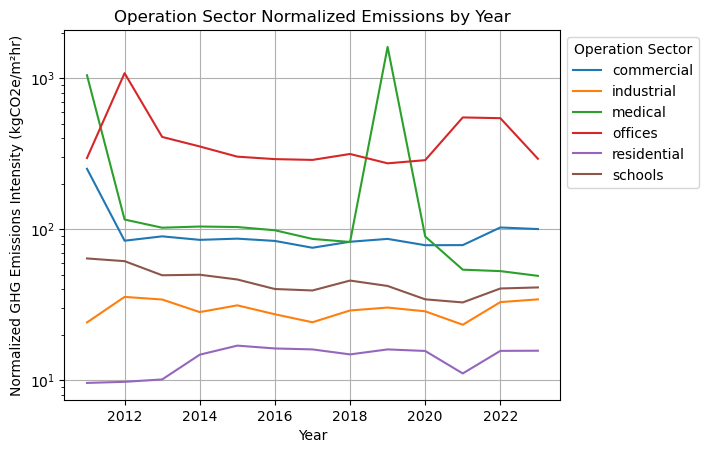

In [42]:
import matplotlib.pyplot as plt
#Running validation tests based on removal of outliers
df = ontario_emissions_df.copy()
df['GHG Emissions (1000 KG CO2e)'] = df.loc[df['Property GFA (m²)'] >= 9290, 'GHG Emissions (1000 KG CO2e)'] #9290 m^2 value found in ontario webpage data: 100,000 feet^2 
df['GHG Emissions (1000 KG CO2e)'] = df.loc[df['Weekly Average Hours'] > 0, 'GHG Emissions (1000 KG CO2e)']
df = df[df['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] < 100000] #Used to remove large outliers in Normalized GHG Emissions, Not used in main dataset however...

df = df[df['Property GFA (m²)'] >= 9290]
#NOTE: Kept as a seperate DataFrame for now until we resolve some of the inherent issues in the
#      normalization procedure.

grouped_year_os = df.groupby(['Year', 'Operation_Sector'])
sums_by_year_and_os = grouped_year_os[['Normalized GHG Emissions Intensity (kgCO2e/m²hr)']].sum().reset_index()

plt.yscale("log");
for sector, group in sums_by_year_and_os.groupby('Operation_Sector'):
    plt.plot(group['Year'],
             group['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'],
             label=sector
            );
plt.xlabel('Year');
plt.ylabel('Normalized GHG Emissions Intensity (kgCO2e/m²hr)');
plt.legend(title='Operation Sector', bbox_to_anchor=(1,1));
plt.title('Operation Sector Normalized Emissions by Year');
plt.grid(True);
#NOTE THAT THIS PLOT AND THAT IN THE FOLLOWING CELL ARE VERY WRONG as we'd expect a dip in 2020 due to Covid-19 and a relatively
#    stable line per operation sector all the other prior years (<2020)

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector
28412,2019,public hospital,acute hospital,Toronto Mount Sinai Hospital,Mount Sinai Hospital,medical,Toronto,M5T 3H7,14056.223900,168.00000,3242.231473,2.697406e+06,2.697406e+06,1142.268738,191901.147941,medical
156078,2011,public hospital,acute/chronic,Toronto University Health Network,Toronto Medical Discovery Tower,medical,Toronto,M5G 1L7,35108.879827,168.00000,2610.926457,5.452489e+06,5.452489e+06,924.418259,155302.267549,medical
28410,2019,public hospital,acute hospital,Toronto Mount Sinai Hospital,Mount Sinai Hospital,medical,Toronto,M5G 1X5,115478.429000,168.00000,1054.954030,7.217241e+06,7.217241e+06,372.015520,62498.607375,medical
184357,2022,municipal,municipality,City of London,CITY HALL,office,LONDON,N6B 1Z2,16257.100000,126.00000,583.120000,5.973594e+05,5.973594e+05,291.623206,36744.523931,offices
198510,2021,municipal,municipality,City of London,CITY HALL,office,LONDON,N6B 1Z2,16257.100000,126.00000,569.560000,5.833519e+05,5.833519e+05,284.784924,35882.900394,offices
175045,2023,municipal,municipality,City of London,CITY HALL,office,LONDON,N6B 1Z2,16257.100000,126.00000,560.670000,5.742506e+05,5.742506e+05,280.341786,35323.064999,offices
143245,2012,school board,school board,Durham District School Board,Cadarackque P.S.,administrative,Oshawa,L1H6C9,33475.221415,45.00000,405.715568,8.576776e+04,8.576776e+04,56.936152,2562.126861,offices
143254,2012,school board,school board,Durham District School Board,Valley View P.S.,administrative,Oshawa,L1G6A2,36332.488618,94.00000,256.440271,7.783419e+04,7.783419e+04,22.790162,2142.275230,offices
143237,2012,school board,school board,Durham District School Board,Alexander Graham Bell P.S.,administrative,Cannington,L0E1E0,50245.933762,52.00000,217.728586,6.943624e+04,6.943624e+04,26.575530,1381.927569,offices
143242,2012,school board,school board,Durham District School Board,Bolton C Falby P.S.,administrative,Ajax,L1S1M5,54148.379096,31.00000,116.332626,5.203882e+04,5.203882e+04,31.001328,961.041170,offices


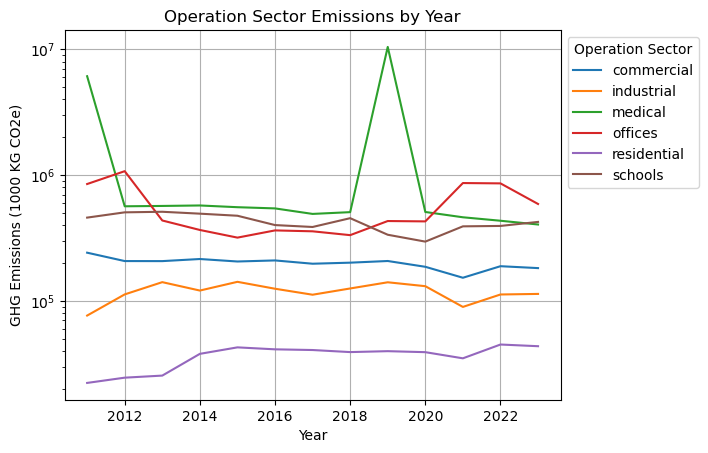

In [43]:
grouped_year_os = df.groupby(['Year', 'Operation_Sector'])
sums_by_year_and_os = grouped_year_os[['GHG Emissions (1000 KG CO2e)']].sum().reset_index()

plt.yscale("log");
for sector, group in sums_by_year_and_os.groupby('Operation_Sector'):
    plt.plot(group['Year'],
             group['GHG Emissions (1000 KG CO2e)'],
             label=sector
            );
plt.xlabel('Year');
plt.ylabel('GHG Emissions (1000 KG CO2e)');
plt.legend(title='Operation Sector', bbox_to_anchor=(1,1));
plt.title('Operation Sector Emissions by Year');
plt.grid(True);
#Plot shows some severe outliers in offices, and medical andemergency services

df.nlargest(20, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)')

In [44]:
#From the above graph, we see a large medical outlier... this was found in the below nlargest output
ontario_emissions_df.nlargest(50, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)')
#Adjusting large outlier form 2019 dataset Mount Sinai Hospital
index_to_impute = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Mount Sinai Hospital')
                    & (ontario_emissions_df['Year'] == 2019)
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute hospital')].index
#Since this is a lone value outlier, we can impute the value based on previous years for the same location, operation, etc
mean_value = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Mount Sinai Hospital')
                    & (ontario_emissions_df['Year'] < 2019)
                    & (ontario_emissions_df['Postal Code'] == 'M5G1X5')
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute hospital')]['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].mean()
ontario_emissions_df.loc[index_to_impute, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)'] = mean_value

#We will now impute the same thing for the GHG Emissions column to correct the outlier
mean_value2 = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Mount Sinai Hospital')
                    & (ontario_emissions_df['Year'] < 2019)
                    & (ontario_emissions_df['Postal Code'] == 'M5G1X5')
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute hospital')]['GHG Emissions (1000 KG CO2e)'].mean()
ontario_emissions_df.loc[index_to_impute, 'GHG Emissions (1000 KG CO2e)'] = mean_value2

#We will also do this for the Normalized value
mean_value3 = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Mount Sinai Hospital')
                    & (ontario_emissions_df['Year'] < 2019)
                    & (ontario_emissions_df['Postal Code'] == 'M5G1X5')
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute hospital')]['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].mean()
ontario_emissions_df.loc[index_to_impute, 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] = mean_value3

In [45]:
#We will do the same thing for 2011 'Toronto Medical Discovery Tower' from 2012's data
index_to_impute = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Toronto Medical Discovery Tower')
                    & (ontario_emissions_df['Year'] == 2011)
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute/chronic')].index

#Since this is a lone value outlier, we can impute the value based on previous years for the same location, operation, etc
mean_value = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Toronto Medical Discovery Tower')
                    & (ontario_emissions_df['Year'] == 2012)
                    & (ontario_emissions_df['Postal Code'] == 'M5G1L7')
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute/chronic')]['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].mean()
ontario_emissions_df.loc[index_to_impute, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)'] = mean_value

#We will now impute the same thing for the GHG Emissions column to correct the outlier
mean_value2 = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Toronto Medical Discovery Tower')
                    & (ontario_emissions_df['Year'] == 2012)
                    & (ontario_emissions_df['Postal Code'] == 'M5G1L7')
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute/chronic')]['GHG Emissions (1000 KG CO2e)'].mean()
ontario_emissions_df.loc[index_to_impute, 'GHG Emissions (1000 KG CO2e)'] = mean_value2

#We will also do this for the Normalized value
mean_value3 = ontario_emissions_df[(ontario_emissions_df['Operation'] == 'Toronto Medical Discovery Tower')
                    & (ontario_emissions_df['Year'] == 2012)
                    & (ontario_emissions_df['Postal Code'] == 'M5G1L7')
                    & (ontario_emissions_df['Weekly Average Hours'] == 168.0)
                    & (ontario_emissions_df['Subsector'] == 'acute/chronic')]['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].mean()
ontario_emissions_df.loc[index_to_impute, 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] = mean_value3

In [46]:
# Looking at the 10 largest emissions contributors, we can see that one school board consistently shows up in 2013
ontario_emissions_df.nlargest(10, 'GHG Emissions (1000 KG CO2e)')

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector
124539,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique L'Odyssée,administrative,North Bay,P1B 0A8,6678.517961,45.0,639374.275624,2.801573e+08,2.801573e+08,9.322005e+05,4.194902e+07,offices
124534,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Héritage,administrative,North Bay,P1B 0A3,4676.272505,45.0,682459.206265,2.087716e+08,2.087716e+08,9.921084e+05,4.464488e+07,offices
124542,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Renaissance,administrative,Timmins,P4R 1N5,6211.773289,45.0,485915.828268,1.968520e+08,1.968520e+08,7.042256e+05,3.169015e+07,offices
124527,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Coeur du Nord,administrative,Kapuskasing,P5N 2B3,2894.857480,45.0,656584.808291,1.269496e+08,1.269496e+08,9.745220e+05,4.385349e+07,offices
124529,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique des Navigateurs,administrative,Temiskaming Shores,P0J 1P0,2677.743169,45.0,587989.129065,1.027856e+08,1.027856e+08,8.530035e+05,3.838516e+07,offices
124543,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,Siege Sociale,administrative,North Bay,P1A 2G8,2204.588190,45.0,680894.708050,9.843977e+07,9.843977e+07,9.922717e+05,4.465223e+07,offices
124535,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Jeunesse Active,administrative,Sturgeon Falls,P2B 3H4,3433.230365,45.0,417062.510606,9.340287e+07,9.340287e+07,6.045675e+05,2.720554e+07,offices
124538,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Lionel Gauthier,administrative,Timmins,P4N 3P9,3020.833948,45.0,376525.394313,7.360319e+07,7.360319e+07,5.414487e+05,2.436519e+07,offices
124531,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Étoile du Nord,administrative,Iroquois Falls,P0K 1G0,1672.254000,45.0,330799.691929,3.616226e+07,3.616226e+07,4.805525e+05,2.162486e+07,offices
124526,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,Centre d'education alternative du Nord-Est de ...,administrative,North Bay,P1B 4W2,362.321700,45.0,818280.997936,1.949110e+07,1.949110e+07,1.195444e+06,5.379500e+07,offices


In [47]:
cspdn_df = ontario_emissions_df[(ontario_emissions_df['Organization'].str.contains('Conseil scolaire public du Nord')) & (ontario_emissions_df['Sector'] == "school board")]
cspdn_df.groupby('Year')['GHG Emissions (1000 KG CO2e)'].describe()
# print(cspdn_df.groupby('Year')['GHG Emissions Intensity (kgCO2e/m²)'].describe())
# cspdn_df.groupby('Year')['Property GFA (m²)'].describe()
# cspdn_df.groupby('Year')['Weekly Average Hours'].describe()


,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,22.0,9.556760e+01,1.546551e+02,0.790140,3.522969,3.140051e+01,1.133189e+02,6.698659e+02
2012,18.0,6.404073e+01,8.578905e+01,0.738320,2.654621,2.016152e+01,8.570546e+01,2.666767e+02
2013,19.0,6.538532e+07,8.557139e+07,82489.127482,452243.751289,1.949110e+07,1.006127e+08,2.801573e+08
2014,14.0,8.607753e+01,8.186228e+01,4.130887,12.773275,7.231412e+01,1.190417e+02,2.569544e+02
2015,13.0,9.372302e+01,7.356902e+01,4.151538,58.650043,8.184044e+01,1.074871e+02,2.403054e+02
2016,13.0,1.041424e+02,9.800725e+01,5.955295,53.679597,8.412822e+01,1.243040e+02,3.556713e+02
2017,13.0,1.089345e+02,1.094319e+02,6.413955,43.874540,7.032919e+01,1.217164e+02,4.017170e+02
2018,13.0,9.661607e+01,7.178037e+01,7.291642,47.192725,8.102016e+01,1.265538e+02,2.345090e+02
2019,14.0,8.560200e+01,6.105447e+01,5.944158,44.725784,7.775797e+01,1.137475e+02,1.929403e+02


In [48]:
cspdn_df = cspdn_df.drop_duplicates(subset = ['Sector', 'Subsector', 'Organization', 'Operation', 'Postal Code', 'City', 'Year', 'Property GFA (m²)'])
cspdn_df[cspdn_df['Year']==2013]

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector
124525,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,Centre d'education alternative du Nord-Est de ...,administrative,North Bay,P1B 4W2,17.465764,45.0,126366.630757,8.248913e+04,8.248913e+04,1.049534e+05,4.722904e+06,offices
124526,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,Centre d'education alternative du Nord-Est de ...,administrative,North Bay,P1B 4W2,362.321700,45.0,818280.997936,1.949110e+07,1.949110e+07,1.195444e+06,5.379500e+07,offices
124527,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Coeur du Nord,administrative,Kapuskasing,P5N 2B3,2894.857480,45.0,656584.808291,1.269496e+08,1.269496e+08,9.745220e+05,4.385349e+07,offices
124528,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Coeur du Nord,administrative,Kapuskasing,P5N 2B3,95.968799,45.0,766967.777349,2.652285e+06,2.652285e+06,6.141544e+05,2.763695e+07,offices
124529,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique des Navigateurs,administrative,Temiskaming Shores,P0J 1P0,2677.743169,45.0,587989.129065,1.027856e+08,1.027856e+08,8.530035e+05,3.838516e+07,offices
124530,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique des Navigateurs,administrative,Temiskaming Shores,P0J 1P0,77.945617,45.0,116827.482433,3.723566e+05,3.723566e+05,1.061585e+05,4.777133e+06,offices
124531,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Étoile du Nord,administrative,Iroquois Falls,P0K 1G0,1672.254000,45.0,330799.691929,3.616226e+07,3.616226e+07,4.805525e+05,2.162486e+07,offices
124532,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Étoile du Nord,administrative,Iroquois Falls,P0K 1G0,65.032100,46.0,56886.860070,1.494996e+05,1.494996e+05,4.997518e+04,2.298858e+06,offices
124533,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Héritage,administrative,North Bay,P1B 0A3,109.997152,45.0,122276.529127,5.321309e+05,5.321309e+05,1.075040e+05,4.837679e+06,offices
124534,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Héritage,administrative,North Bay,P1B 0A3,4676.272505,45.0,682459.206265,2.087716e+08,2.087716e+08,9.921084e+05,4.464488e+07,offices


In [49]:
# Create a new dataset based only on this school board across all years
cspdn_df = ontario_emissions_df[(ontario_emissions_df['Organization'].str.contains('Conseil scolaire public du Nord')) & (ontario_emissions_df['Sector'] == "school board")]

# We can see from the output of the command below that the 2013 data is indeed a huge outlier, suggesting erroneous entries this year.
cspdn_df.groupby('Year')['GHG Emissions (1000 KG CO2e)'].describe()

# Drop duplicates for schools in same year of operation with the same name and postal code
cspdn_df = cspdn_df.drop_duplicates(subset = ['Operation', 'Operation Type', 'Postal Code', 'City', 'Year'])

# First lets get the 2013 rows
subset_2013 = cspdn_df.loc[cspdn_df['Year'] == 2013, :]

# Now lets run a for loop replace the emissions values
for idx, row in subset_2013.iterrows():
  # Calculate the mean emissions using data from other years
  mean_emissions = cspdn_df.loc[(cspdn_df['Year'] != 2013) & (cspdn_df['Operation'] == row['Operation']) & (cspdn_df['Postal Code'] == row['Postal Code']), 'GHG Emissions (1000 KG CO2e)'].mean()
  row['GHG Emissions (1000 KG CO2e)'] = mean_emissions
  row['GHG Emissions Intensity Recalculated (kgCO2e/m²)'] = (row['GHG Emissions (1000 KG CO2e)']*1000)/row['Property GFA (m²)']
  row['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'] = row['GHG Emissions Intensity Recalculated (kgCO2e/m²)']/row['Weekly Average Hours']

  # Replace the row in the cspdn_df dataframe
  cspdn_df.loc[idx] = row

# Replace target rows in the original dataframe
ontario_emissions_df.update(cspdn_df)

In [50]:
# We can see below that the issue has been resolved for the 2013 data for this school council
cspdn_df.groupby('Year')['GHG Emissions (1000 KG CO2e)'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,12.0,170.466839,179.300950,22.204787,60.218388,110.680684,238.259870,669.865864
2012,10.0,110.188000,92.342883,1.402779,43.840392,82.263533,190.324425,266.676675
2013,10.0,116.558838,73.392660,17.990634,65.118904,103.149070,146.681909,240.696562
2014,14.0,86.077530,81.862280,4.130887,12.773275,72.314118,119.041708,256.954362
2015,13.0,93.723016,73.569020,4.151538,58.650043,81.840437,107.487122,240.305407
2016,13.0,104.142423,98.007254,5.955295,53.679597,84.128225,124.304034,355.671254
2017,13.0,108.934535,109.431926,6.413955,43.874540,70.329193,121.716435,401.717013
2018,13.0,96.616072,71.780370,7.291642,47.192725,81.020157,126.553841,234.508980
2019,14.0,85.601997,61.054466,5.944158,44.725784,77.757965,113.747482,192.940349


In [51]:
# So it looks like some big values still were retained but this is because there are duplicates in the original dataset with different values for the emissions
# If we remove these duplicate values it should solve the issue - see below
ontario_emissions_df.nlargest(10, 'GHG Emissions (1000 KG CO2e)')

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector
124534,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Héritage,administrative,North Bay,P1B 0A3,4676.272505,45.0,682459.206265,2.087716e+08,2.087716e+08,9.921084e+05,4.464488e+07,offices
124542,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Renaissance,administrative,Timmins,P4R 1N5,6211.773289,45.0,485915.828268,1.968520e+08,1.968520e+08,7.042256e+05,3.169015e+07,offices
124538,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Lionel Gauthier,administrative,Timmins,P4N 3P9,3020.833948,45.0,376525.394313,7.360319e+07,7.360319e+07,5.414487e+05,2.436519e+07,offices
124526,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,Centre d'education alternative du Nord-Est de ...,administrative,North Bay,P1B 4W2,362.321700,45.0,818280.997936,1.949110e+07,1.949110e+07,1.195444e+06,5.379500e+07,offices
124528,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique Coeur du Nord,administrative,Kapuskasing,P5N 2B3,95.968799,45.0,766967.777349,2.652285e+06,2.652285e+06,6.141544e+05,2.763695e+07,offices
124540,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique L'Odyssée,administrative,North Bay,P1B 0A8,224.174939,45.0,104353.486379,8.923426e+05,8.923426e+05,8.845697e+04,3.980564e+06,offices
184357,2022,municipal,municipality,City of London,CITY HALL,office,LONDON,N6B 1Z2,16257.100000,126.0,583.120000,5.973594e+05,5.973594e+05,2.916232e+02,3.674452e+04,offices
198510,2021,municipal,municipality,City of London,CITY HALL,office,LONDON,N6B 1Z2,16257.100000,126.0,569.560000,5.833519e+05,5.833519e+05,2.847849e+02,3.588290e+04,offices
175045,2023,municipal,municipality,City of London,CITY HALL,office,LONDON,N6B 1Z2,16257.100000,126.0,560.670000,5.742506e+05,5.742506e+05,2.803418e+02,3.532306e+04,offices
124530,2013,school board,school board,Conseil scolaire public du Nord?Est de l'Ontario,École Publique des Navigateurs,administrative,Temiskaming Shores,P0J 1P0,77.945617,45.0,116827.482433,3.723566e+05,3.723566e+05,1.061585e+05,4.777133e+06,offices


In [52]:
drop_duplicates_test = ontario_emissions_df.drop_duplicates(subset = ['Sector', 'Subsector', 'Organization', 'Operation', 'Operation Type', 'Postal Code', 'Weekly Average Hours', 'Year'])
ontario_emissions_df.info()
print(len(ontario_emissions_df) - len(drop_duplicates_test))
ontario_emissions_df = drop_duplicates_test
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205349 entries, 0 to 212270
Data columns (total 16 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              205349 non-null  int64  
 1   Sector                                            205349 non-null  object 
 2   Subsector                                         205349 non-null  object 
 3   Organization                                      205349 non-null  object 
 4   Operation                                         205349 non-null  object 
 5   Operation Type                                    205349 non-null  object 
 6   City                                              205348 non-null  object 
 7   Postal Code                                       205209 non-null  object 
 8   Property GFA (m²)                                 202253 non-null  float64
 9   Weekly Av

In [53]:
ontario_emissions_df.nlargest(10, 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)')

#Note that there are 2 large outlier in the 2013 & 2018 dataset that will be dropped.
ontario_emissions_df = ontario_emissions_df[ontario_emissions_df['GHG Emissions Intensity Recalculated (kgCO2e/m²)'] < 314849]
ontario_emissions_df.nlargest(10, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)')

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector
185973,2022,municipal,municipality,City of Toronto,Allan A Lamport Stadium,other - public services,Toronto,M6K 1E9,2.000000,92.551431,7672.600000,515.200000,515.200000,2783.317322,257600.000000,commercial
181766,2023,municipal,municipality,City of Toronto,Allan A Lamport Stadium,other - public services,Toronto,M6K 1E9,2.000000,92.217243,6458.760000,363.800000,363.800000,1972.516131,181900.000000,commercial
158388,2011,municipal,municipality,City of Owen Sound,Water Treatment Plant,industrial - water,Owen Sound,N4K 2M6,2.000000,168.000000,5005.026000,272.607083,272.607083,811.330604,136303.541400,industrial
175096,2023,municipal,municipality,City of London,J Allyn Taylor Building,office,LONDON,N6A 1H2,2425.700000,168.000000,1239.100000,189497.000000,189497.000000,465.003229,78120.542524,offices
38288,2018,municipal,municipality,City of Toronto,Davisville Garage & Shop,commercial,Toronto,M4S 3C4,5.574180,70.000000,4279.882457,420.351469,420.351469,1077.292264,75410.458450,commercial
129686,2013,municipal,municipality,Region of Peel,Corporate Office - Suite B,administrative,Brampton,L6T 4B9,16.169024,45.000000,2139.724824,1181.416181,1181.416181,1623.703016,73066.635717,offices
147405,2012,municipal,municipality,Region of Peel,Corporate Office - Suite B,administrative,Brampton,L6T4B9,16.169024,45.000000,1958.534961,1131.433497,1131.433497,1555.008312,69975.374055,offices
139718,2012,municipal,municipality,City of Owen Sound,Streetlights,other - streetlights,Owen Sound,N4K2H4,2.000000,84.000000,2553.638400,136.250796,136.250796,811.016640,68125.397760,industrial
173210,2011,municipal,municipality,County of Prince Edward,Town Hall Sophiasburgh,cultural facilities,Demorestville,K0K 1W0,149.759636,68.000000,957.277292,10076.615074,10076.615074,989.489022,67285.253514,commercial
54951,2017,municipal,municipality,City of Toronto,Davisville Garage & Shop,commercial,Toronto,M4S 3C4,5.574180,70.000000,4279.882457,357.713493,357.713493,916.761346,64173.294189,commercial


## Join latitute to emissions data as proxy for cold weather effects
Note that this section is here to showcase work that was done, but didn't end in any major findings. The section still has some data cleaning involved that we are using. \
\
Weather, particularly cold weather in Canada, is a major determinant of a building's energy use and GHG emissions. In the absence of reliable data on weather-normalized energy use, we will use latitude as a proxy for building exposure to cold weather

A publicly available dataset with all postal codes for Canada will be joined to the emissions data to provide latitude of each building
Data taken from the following website: https://www.serviceobjects.com/blog/free-zip-code-and-postal-code-database-with-geocoordinates/
(data must first be downloaded by completing a user form, there doesn't appear to be a way to access it directly via API)

In [55]:
# first check the postal codes entered by respondents in the Ontario emissions data: there may be some variability which will compromise the join

import re
ontario_emissions_df.info()
pc_pattern = r"^([A-Z][0-9][A-Z][ ][0-9][A-Z][0-9])$"

ontario_emissions_df["Postal Code"].str.contains(pc_pattern).value_counts()
ontario_emissions_df['Postal Code'] = ontario_emissions_df['Postal Code'].str.replace('-', '') # remove dash between 3 character sequences

ontario_emissions_df['Postal Code'] = ontario_emissions_df['Postal Code'].str.replace(' ', '') # remove space between 3 character sequences

pc_prob1 = r"^([A-Z][0-9][A-Z][0-9][A-Z][0-9])$"

ontario_emissions_df["Postal Code"].str.contains(pc_prob1).value_counts()
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177702 entries, 0 to 212270
Data columns (total 16 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              177702 non-null  int64  
 1   Sector                                            177702 non-null  object 
 2   Subsector                                         177702 non-null  object 
 3   Organization                                      177702 non-null  object 
 4   Operation                                         177702 non-null  object 
 5   Operation Type                                    177702 non-null  object 
 6   City                                              177701 non-null  object 
 7   Postal Code                                       177619 non-null  object 
 8   Property GFA (m²)                                 177702 non-null  float64
 9   Weekly Av

C:\Users\vande\AppData\Local\Temp\ipykernel_2824\3875064542.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ontario_emissions_df["Postal Code"].str.contains(pc_pattern).value_counts()
C:\Users\vande\AppData\Local\Temp\ipykernel_2824\3875064542.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ontario_emissions_df['Postal Code'] = ontario_emissions_df['Postal Code'].str.replace('-', '') # remove dash between 3 character sequences
C:\Users\vande\AppData\Local\Temp\ipykernel_2824\3875064542.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

<class 'pandas.core.frame.DataFrame'>
Index: 177702 entries, 0 to 212270
Data columns (total 16 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              177702 non-null  int64  
 1   Sector                                            177702 non-null  object 
 2   Subsector                                         177702 non-null  object 
 3   Organization                                      177702 non-null  object 
 4   Operation                                         177702 non-null  object 
 5   Operation Type                                    177702 non-null  object 
 6   City                                              177701 non-null  object 
 7   Postal Code                                       177617 non-null  object 
 8   Property GFA (m²)                                 177702 non-null  float64
 9   Weekly Av

In [56]:
# read in the PC dataset
pcode = pd.read_csv('CanadianPostalCodes202403.csv', usecols=['POSTAL_CODE', 'LATITUDE'])

pcode.head()

# collapse the space in the middle of PC to align it with emissions dataset
pcode['POSTAL_CODE'] = pcode['POSTAL_CODE'].str.replace(' ', '')

pcode = pcode.rename(columns={"POSTAL_CODE": "Postal Code"})

pcode = pcode.drop_duplicates()

# join latitude to the emissions data on postal code
ontario_emissions_df = ontario_emissions_df.merge(pcode, how='left', on='Postal Code')

ontario_emissions_df.sort_values('LATITUDE').head()
ontario_emissions_df['LATITUDE'].isnull().value_counts()
ontario_emissions_df[pd.isnull(ontario_emissions_df['LATITUDE'])].head(10)
ontario_emissions_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178555 entries, 0 to 178554
Data columns (total 17 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              178555 non-null  int64  
 1   Sector                                            178555 non-null  object 
 2   Subsector                                         178555 non-null  object 
 3   Organization                                      178555 non-null  object 
 4   Operation                                         178555 non-null  object 
 5   Operation Type                                    178555 non-null  object 
 6   City                                              178554 non-null  object 
 7   Postal Code                                       178470 non-null  object 
 8   Property GFA (m²)                                 178555 non-null  float64
 9   Week

The missing values for latitude appear to be due to non-valid PCs: some are just 3 digits, some have digits in inappropriate places (e.g., "L75" should end with a letter), and some appear to be not listed in the master PC list for unknown reasons (e.g., P2A3E5)

Almost all PCs are in the right format now. For some of the rest with only 3 digits given, we could try to build a fake ending but for now will just leave it at that as I will have to think about more about how to do that using regex.

# Write data to excel file for further analysis
Data cleaning is complete! Writing the data to an excel file for use in data exploration and analysis (see accompnaying Jupyter notebook) 

In [59]:
ontario_emissions_df.to_excel("emissions_for_analysis_20241209.xlsx")
cleaned_df = ontario_emissions_df.copy()

In [60]:
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178555 entries, 0 to 178554
Data columns (total 17 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              178555 non-null  int64  
 1   Sector                                            178555 non-null  object 
 2   Subsector                                         178555 non-null  object 
 3   Organization                                      178555 non-null  object 
 4   Operation                                         178555 non-null  object 
 5   Operation Type                                    178555 non-null  object 
 6   City                                              178554 non-null  object 
 7   Postal Code                                       178470 non-null  object 
 8   Property GFA (m²)                                 178555 non-null  float64
 9   Week

# Read in data file for exploration and analysis

In [62]:
#import pandas as pd

In [63]:
#ontario_emissions_df = pd.read_excel("emissions_for_analysis_20241209.xlsx")

In [64]:
ontario_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178555 entries, 0 to 178554
Data columns (total 17 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   Year                                              178555 non-null  int64  
 1   Sector                                            178555 non-null  object 
 2   Subsector                                         178555 non-null  object 
 3   Organization                                      178555 non-null  object 
 4   Operation                                         178555 non-null  object 
 5   Operation Type                                    178555 non-null  object 
 6   City                                              178554 non-null  object 
 7   Postal Code                                       178470 non-null  object 
 8   Property GFA (m²)                                 178555 non-null  float64
 9   Week

In [65]:
ontario_emissions_df.describe(include='all')

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector,LATITUDE
count,178555.000000,178555,178555,178555,178555,178555,178554,178470,1.785550e+05,178555.000000,177503.000000,178555.000000,1.785550e+05,178555.000000,178555.000000,178555,175666.000000
unique,NaN,6,15,771,25550,85,1526,11296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,municipal,municipality,City of Toronto,Municipal Office,administrative,Toronto,K0L2H0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,offices,NaN
freq,NaN,106946,106653,11146,732,71186,18666,996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72173,NaN
mean,2016.612853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.834792e+04,76.860746,24.543171,200.727671,4.372231e+03,3.026298,63.111704,NaN,44.346062
std,3.582805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.104396e+06,185.200679,3341.640385,2915.904841,8.364333e+05,125.771694,1086.291600,NaN,1.554762
min,2011.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.100000e+00,0.000000,-0.020000,-43.000000,-4.300000e+01,-0.215250,-10.763454,NaN,41.809171
25%,2014.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.330000e+02,40.000000,0.601017,8.911134,8.911134e+00,0.231240,16.444258,NaN,43.442950
50%,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.521800e+03,60.000000,0.866369,43.500000,4.350000e+01,0.434400,28.601690,NaN,43.838045
75%,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.439998e+03,96.000000,1.370000,114.163877,1.141761e+02,0.802522,45.365675,NaN,44.906060


In [66]:
ontario_emissions_df.head()

,Year,Sector,Subsector,Organization,Operation,Operation Type,City,Postal Code,Property GFA (m²),Weekly Average Hours,Source EUI (GJ/m²),GHG Emissions (1000 KG CO2e),GHG Emissions Intensity (kgCO2e/m²),Normalized GHG Emissions Intensity (kgCO2e/m²hr),GHG Emissions Intensity Recalculated (kgCO2e/m²),Operation_Sector,LATITUDE
0,2020,public hospital,acute/chronic hospital,Alexandra Hospital,"Alexandra Hospital, Ingersoll",medical,Ingersoll,N5C3V6,8473.988151,168.0,2.753541,850.748303,850.748303,0.597591,100.395267,medical,43.037474
1,2020,school board,school board,Algoma District School Board,Ben R McMullin PS,administrative,Sault Ste. Marie,P6B5K2,2052.999294,50.0,0.976749,77.791064,77.791064,0.757828,37.891423,offices,46.524249
2,2020,school board,school board,Algoma District School Board,Blind River PS,administrative,Blind River,P0R1B0,4481.998397,50.0,0.447410,77.792354,77.792354,0.347132,17.356623,offices,46.182449
3,2020,school board,school board,Algoma District School Board,Central Algoma SS,administrative,Desbarats,P0R1E0,10486.992833,50.0,1.210610,488.110028,488.110028,0.930887,46.544327,offices,46.357516
4,2020,school board,school board,Algoma District School Board,Boreal FI,administrative,Sault Ste. Marie,P6B4H6,12069.994921,50.0,0.695751,320.655802,320.655802,0.531327,26.566358,offices,46.534087


# DATA EXPLORATION
Note that preliminary data exploration has already been done. A round of exploration is shown below on the cleaned dataset prior to starting our analysis.

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

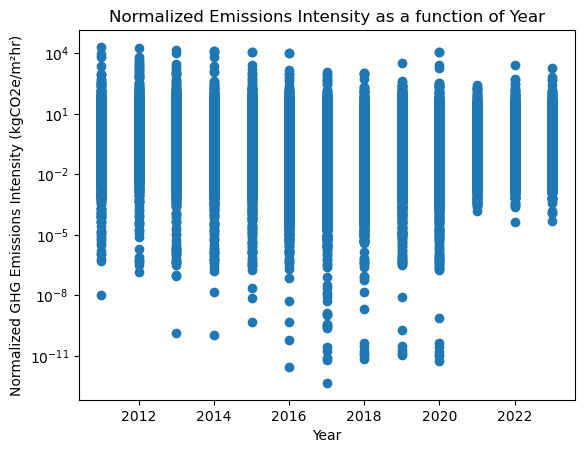

In [69]:
plt.yscale("log");
plt.scatter(ontario_emissions_df['Year'], ontario_emissions_df['Normalized GHG Emissions Intensity (kgCO2e/m²hr)']);
plt.title('Normalized Emissions Intensity as a function of Year');
plt.xlabel('Year');
plt.ylabel('Normalized GHG Emissions Intensity (kgCO2e/m²hr)');

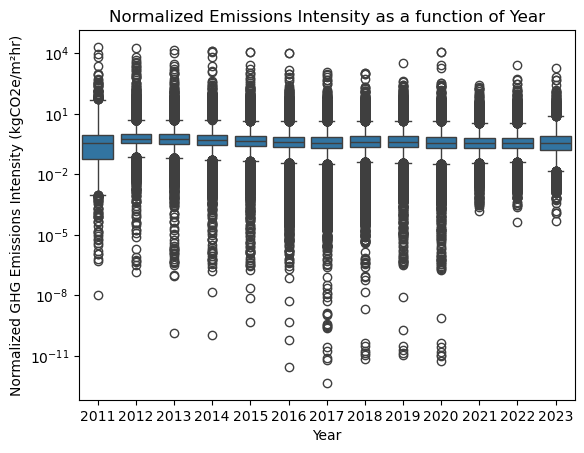

In [70]:
plt.yscale("log");
plt.title('Normalized Emissions Intensity as a function of Year');
sns.boxplot(x='Year', y='Normalized GHG Emissions Intensity (kgCO2e/m²hr)', data=ontario_emissions_df);

In [71]:
# view above as a table
ontario_emissions_df.groupby('Year')['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,14449.0,4.456288,201.102829,0.000000e+00,0.056378,0.351282,0.867633,21068.994701
2012,15337.0,5.422680,181.872738,1.529520e-07,0.347840,0.593585,0.990416,19466.721759
2013,14448.0,4.429317,153.970947,0.000000e+00,0.341551,0.574090,1.000049,14239.622722
2014,14897.0,5.007412,190.158522,0.000000e+00,0.291061,0.508993,0.928727,13133.241957
2015,14885.0,3.592556,138.838338,0.000000e+00,0.257138,0.444565,0.821136,11659.876941
2016,15038.0,3.018858,125.738406,0.000000e+00,0.227502,0.406585,0.739859,10777.203297
2017,14551.0,1.416034,17.810901,0.000000e+00,0.204700,0.383766,0.698048,1214.040505
2018,14245.0,1.522771,18.359712,0.000000e+00,0.240855,0.426181,0.772589,1096.704299
2019,14367.0,1.773633,30.444138,0.000000e+00,0.229572,0.412349,0.766064,3486.848612


In the graph, the median of Normalized GHG Emissions Intensity for each year is represented by the horizontal line in the box of each boxplot. From this it appears that there may have been some modest reductions from 2011 until 2020 and this is reflected in the table, which shows the median generally declining each year 2012-2023.

In 2021 and 2022 there was a much lower range of emissions within the interquartile range (IQR) - 25%-75% range of values represented by the upper and lower limits of the box) - particularly the 75% mark.

Another feature of the normalized GHG emissions intensity is the tremendous range in values even though values have been normalized to remove as much as possible the effect of square footage and operating hours. Already this can be seen by the need to plot the values on a log scale. According to the seaborn documentation (https://seaborn.pydata.org/tutorial/categorical.html#boxplots), the "whiskers" coming off of the boxes in the boxplot represent values that lie within 1.5 IQRs of the upper and lower quartile, i.e., the vast majority of the values with exception of more extreme values individually plotted with circles. This large 1.5 IQR looks to be generally topping out at around 100 kg CO2e/m²hr.

A last note on the overall metrics is that 2023 has a reduction in entries of almost half compared to the prior two years, which suggests the data for that year is incomplete.


These extreme values need to be further explored and possibly excluded as it does not seem possible that such massive CO2 output could be occurring.

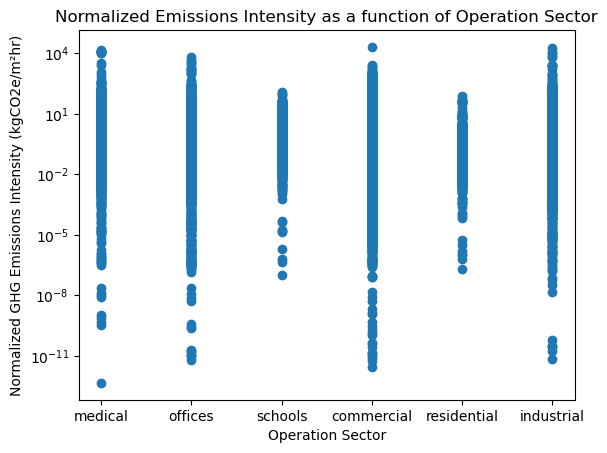

In [73]:
plt.yscale("log");
plt.scatter(ontario_emissions_df['Operation_Sector'], ontario_emissions_df['Normalized GHG Emissions Intensity (kgCO2e/m²hr)']);
plt.title('Normalized Emissions Intensity as a function of Operation Sector');
plt.xlabel('Operation Sector');
plt.ylabel('Normalized GHG Emissions Intensity (kgCO2e/m²hr)');

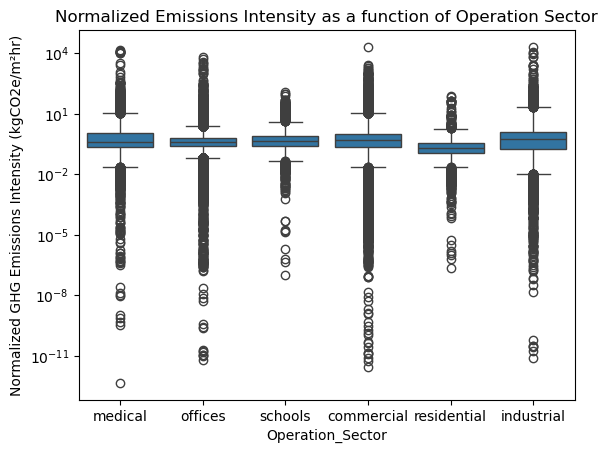

In [74]:
plt.yscale('log');
plt.title('Normalized Emissions Intensity as a function of Operation Sector');
sns.boxplot(x='Operation_Sector', y='Normalized GHG Emissions Intensity (kgCO2e/m²hr)', data=ontario_emissions_df);

In [75]:
# view above as a table
ontario_emissions_df.groupby('Operation_Sector')['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].describe()

,count,mean,std,min,25%,50%,75%,max
Operation_Sector,,,,,,,,
commercial,53342.0,2.763070,96.130351,-0.008757,0.223597,0.511572,1.054386,21068.994701
industrial,21563.0,6.044839,198.294796,0.000000,0.181243,0.563081,1.246151,19466.721759
medical,21476.0,7.868216,251.080359,0.000000,0.228991,0.399529,1.087797,14239.622722
offices,72173.0,1.192965,42.241397,-0.215250,0.254529,0.406819,0.630654,6904.450192
residential,3683.0,0.463896,2.673613,0.000000,0.119455,0.212867,0.363857,74.986334
schools,6318.0,0.924628,3.581261,0.000000,0.243616,0.456769,0.757220,122.878070


Similar to the view of normalized emissions by year, each sector appears to have extreme upper and lower values with offices having the most extreme values.

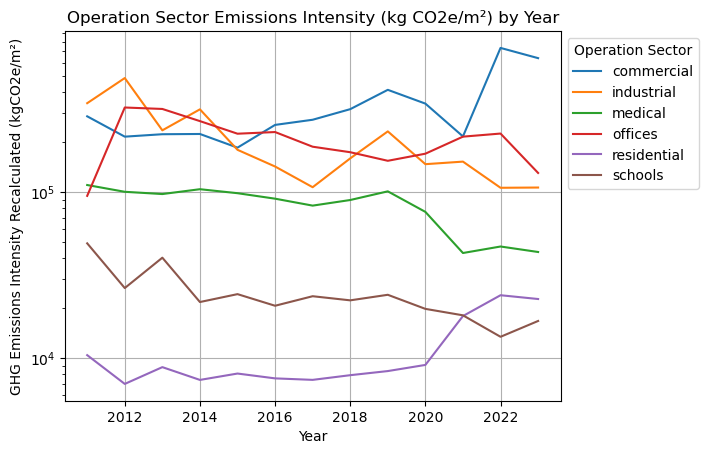

In [77]:
grouped_year_os = ontario_emissions_df.groupby(['Year', 'Operation_Sector'])
sums_by_year_and_os = grouped_year_os[['GHG Emissions Intensity Recalculated (kgCO2e/m²)']].sum().reset_index()

plt.yscale("log");
for sector, group in sums_by_year_and_os.groupby('Operation_Sector'):
    plt.plot(group['Year'],
             group['GHG Emissions Intensity Recalculated (kgCO2e/m²)'],
             label=sector
            );
plt.xlabel('Year');
plt.ylabel('GHG Emissions Intensity Recalculated (kgCO2e/m²)');
plt.legend(title='Operation Sector', bbox_to_anchor=(1,1));
plt.title('Operation Sector Emissions Intensity (kg CO2e/m²) by Year');
plt.grid(True);

From the above graph (GHG Emissions Intensity Relcalculated (kg CO2e/m²), initial inspection shows that the hypothesis of emissions being most volatile by industrial processes is plausible. However, given the plethora of data that incorrectly provided Property GFA, the data is not fully trust-worthy and more analysis is required before finalizing the answer to the hypothesis. As expected from the pandemic, with everyone being isolated at home, a drastic increase in GHG Emissions Intensity is notable in the residential Operation Sector, and a decrease in the majority of other Operation Sectors is notable. What does not make sense is the small uprise in office intensity values in 2020. We'd expect to see this decrease in 2020 and 2021, not an increase. A notable spike is apparent as recovery from the pandemic in some regions began for the commercial Operation Sector in 2022.

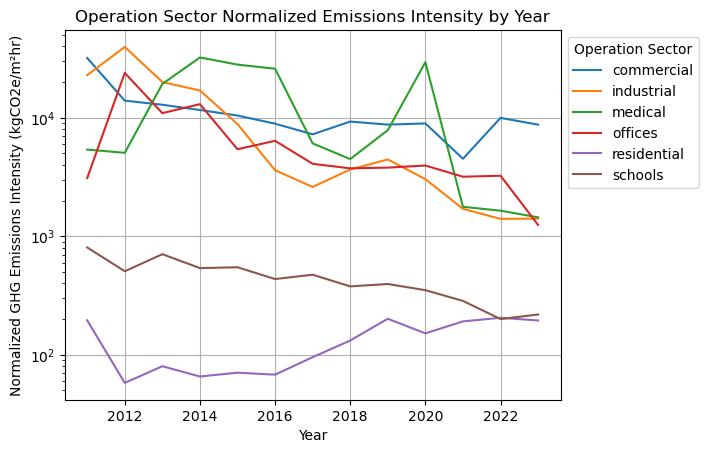

In [79]:
grouped_year_os = ontario_emissions_df.groupby(['Year', 'Operation_Sector'])
sums_by_year_and_os = grouped_year_os[['Normalized GHG Emissions Intensity (kgCO2e/m²hr)']].sum().reset_index()

plt.yscale("log");
for sector, group in sums_by_year_and_os.groupby('Operation_Sector'):
    plt.plot(group['Year'],
             group['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'],
             label=sector
            );
plt.xlabel('Year');
plt.ylabel('Normalized GHG Emissions Intensity (kgCO2e/m²hr)');
plt.legend(title='Operation Sector', bbox_to_anchor=(1,1));
plt.title('Operation Sector Normalized Emissions Intensity by Year');
plt.grid(True);

When viewing the Normalized GHG Emissions Intensity (kg CO2e/m²hr) data, a similar, initial highest emissions rate, is shown by the industrial Operation Sector, being taken over by both commercial and medical. Interestingly, a large spike in the 2020 medical and emergency services Operation Sector is noted. It is plausible that this is caused by the pandemic, however, further analysis is required to know for sure. The decrease seen in 2023 for the offices and commercial Operation Sector makes the accuracy of Property GFA questionable. Many locations had minimal area value, most of which did not make sense.

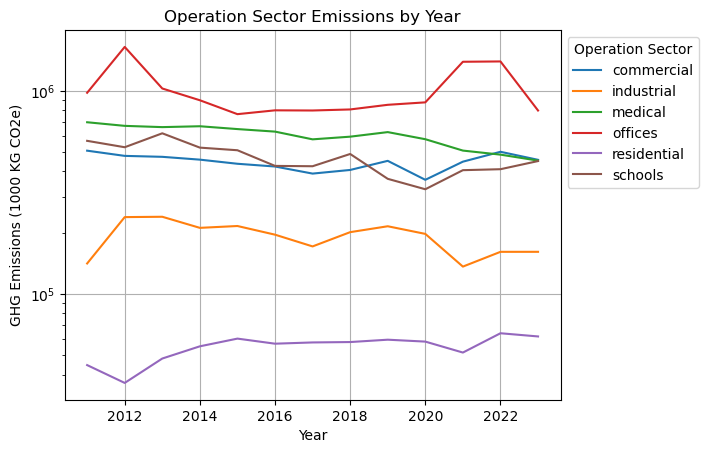

In [81]:
grouped_year_os = ontario_emissions_df.groupby(['Year', 'Operation_Sector'])
sums_by_year_and_os = grouped_year_os[['GHG Emissions (1000 KG CO2e)']].sum().reset_index()

plt.yscale("log");
for sector, group in sums_by_year_and_os.groupby('Operation_Sector'):
    plt.plot(group['Year'],
             group['GHG Emissions (1000 KG CO2e)'],
             label=sector
            );
plt.xlabel('Year');
plt.ylabel('GHG Emissions (1000 KG CO2e)');
plt.legend(title='Operation Sector', bbox_to_anchor=(1,1));
plt.title('Operation Sector Emissions by Year');
plt.grid(True);

## Latitude and energy use

Quick test of whether latitude does indeed correlate with energy use (not using imputed values here for energy)

Latitude is a float value so we can do a scatter plot and regression of latitude on

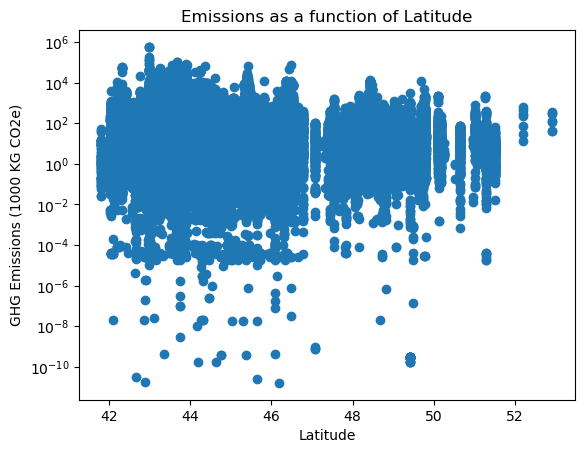

In [83]:
plt.yscale("log");
plt.scatter(ontario_emissions_df['LATITUDE'], ontario_emissions_df['GHG Emissions (1000 KG CO2e)']);
plt.title('Emissions as a function of Latitude');
plt.xlabel('Latitude');
plt.ylabel('GHG Emissions (1000 KG CO2e)');

Note that no discenerable visual trend appears, therefore this will not be included in the final analysis, but instead as something looked into for the normalization stages of data cleaning.

# Basic Statistical Analysis

In [86]:
from scipy import stats

In [87]:
#define a function to apply to a chosen output variable that provides the basic stats & outlier summaries in an easy to read output
def stats_analysis(data, metric_name, sector_variable, year_column='Year'):

    unique_groups = data[sector_variable].unique()
    years = sorted(data[year_column].unique())
    analysis_results = {}
    
    #Collect all results
    for year in years:
        year_data = data[data[year_column] == year]
        
        for group in unique_groups:
            group_data = year_data[year_data[sector_variable] == group][metric_name].dropna()
            
            if len(group_data) < 3:
                continue
            
            #Basic Statistical Analysis
            stats_dict = {'mean': round(group_data.mean(), 2),
                'std': round(group_data.std(), 2),
                'cv': round((group_data.std() / group_data.mean() * 100), 2) if group_data.mean() != 0 else np.nan,
                'q1': round(group_data.quantile(0.25), 2),
                'q3': round(group_data.quantile(0.75), 2),
                'iqr': round(group_data.quantile(0.75) - group_data.quantile(0.25), 2)}
            
            #Outlier Detection
            lower_bound = round(stats_dict['q1'] - 1.5 * stats_dict['iqr'], 2)
            upper_bound = round(stats_dict['q3'] + 1.5 * stats_dict['iqr'], 2)
            outliers = group_data[(group_data < lower_bound) | (group_data > upper_bound)]
            
            #Store results
            if year not in analysis_results:
                analysis_results[year] = {}
            
            analysis_results[year][group] = {'statistics': stats_dict, 'outliers': {'count': len(outliers),
                    'percentage': round((len(outliers) / len(group_data) * 100), 2), 'bounds': (lower_bound, upper_bound)}}
    
    #Create summary DataFrames
    cv_summary = pd.DataFrame(
        {year: {group: analysis_results[year][group]['statistics']['cv'] 
                for group in unique_groups if year in analysis_results and group in analysis_results[year]}
         for year in years}
    ).T.round(2)
    
    std_summary = pd.DataFrame(
        {year: {group: analysis_results[year][group]['statistics']['std']
                for group in unique_groups if year in analysis_results and group in analysis_results[year]}
         for year in years}
    ).T.round(2)
    
    mean_summary = pd.DataFrame(
        {year: {group: analysis_results[year][group]['statistics']['mean']
                for group in unique_groups if year in analysis_results and group in analysis_results[year]}
         for year in years}
    ).T.round(2)
    
    #Print statistical summaries
    print(f"\nCOEFFICIENT OF VARIATION (%) BY YEAR AND SECTOR: {metric_name}")
    print("=" * 80)
    pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
    print(cv_summary)
    
    print(f"\nSTANDARD DEVIATION BY YEAR AND SECTOR: {metric_name}")
    print("=" * 80)
    print(std_summary)
    
    print(f"\nMEAN VALUES BY YEAR AND SECTOR: {metric_name}")
    print("=" * 80)
    print(mean_summary)
    
    #Create outlier DataFrames
    sectors = set()
    for year in analysis_results.keys():
        sectors.update(analysis_results[year].keys())
    sectors = sorted(list(sectors))
    
    outlier_counts = pd.DataFrame(columns=sectors)
    outlier_percentages = pd.DataFrame(columns=sectors)
    outlier_bounds = pd.DataFrame(columns=sectors)
    
    #Extract data for each year and sector
    for year in analysis_results.keys():
        year_counts = {}
        year_percentages = {}
        year_bounds = {}
        
        for sector in sectors:
            if sector in analysis_results[year]:
                outlier_data = analysis_results[year][sector]['outliers']
                year_counts[sector] = outlier_data['count']
                year_percentages[sector] = outlier_data['percentage']
                year_bounds[sector] = f"[{outlier_data['bounds'][0]}, {outlier_data['bounds'][1]}]"
            else:
                year_counts[sector] = 0
                year_percentages[sector] = 0.0
                year_bounds[sector] = "[NA, NA]"
        
        outlier_counts.loc[year] = year_counts
        outlier_percentages.loc[year] = year_percentages
        outlier_bounds.loc[year] = year_bounds
    
    #Print outlier summaries
    print("\nOUTLIER ANALYSIS SUMMARY")
    print("=" * 80)
    
    print("\nNumber of Outliers:")
    print("-" * 40)
    print(outlier_counts.fillna(0).astype(int))
    
    print("\nOutlier Percentage (%):")
    print("-" * 40)
    print(outlier_percentages.round(2))
    
    print("\nOutlier Bounds [Lower, Upper]:")
    print("-" * 40)
    print(outlier_bounds)

    return analysis_results

In [88]:
stats_results = stats_analysis(ontario_emissions_df,'GHG Emissions Intensity Recalculated (kgCO2e/m²)','Operation_Sector');


COEFFICIENT OF VARIATION (%) BY YEAR AND SECTOR: GHG Emissions Intensity Recalculated (kgCO2e/m²)
      medical  offices  schools  commercial  residential  industrial
2011   137.11   379.31   636.91     1527.83       185.83     1569.45
2012    84.80  1749.45   155.69      236.97       139.08      764.88
2013    75.26  1843.24   785.78      361.81       344.20      305.69
2014   168.22  1739.76   104.40      346.08        65.10      861.09
2015   171.99  1705.83   235.83      236.55        66.14      560.66
2016   195.28  1609.29   283.70     1362.79        74.70      303.07
2017   199.91   932.46   475.70     1930.07        90.09      293.72
2018   168.23   121.92   436.77     1889.18        69.34      362.57
2019   376.83   105.09   516.15      821.86        72.42      889.61
2020    97.96   639.56   444.19      815.84       104.24      471.96
2021   118.45  1733.60   336.45     1027.09       208.06      581.94
2022   119.66  2110.15   165.46     2286.26       158.76      209.29
2023

In [89]:
#define a function to assess normality and provide an easy to read output
from scipy.stats import shapiro
import warnings

def normality_analysis(data, metric_name, sector_variable, year_column='Year'):

    unique_sectors = sorted(data[sector_variable].unique())
    years = sorted(data[year_column].unique())

    #Suppress specific Shapiro-Wilk warnings
    warnings.filterwarnings("ignore", category=UserWarning, message=".*scipy.stats.shapiro.*")
    
    #Initialize overall summary
    overall_summary = pd.DataFrame(columns=['Year', 'Sector', 'Shapiro p-value', 'Distribution Type'])
    
    #Calculate Shapiro-Wilk p-values and determine distribution type
    for sector in unique_sectors:
        for year in years:
            year_sector_data = data[
                (data[sector_variable] == sector) & 
                (data[year_column] == year)
            ][metric_name]
            
            if len(year_sector_data) > 2:
                _, shapiro_p = shapiro(year_sector_data)
                shapiro_p = round(shapiro_p, 4)
                distribution_type = 'Normal' if shapiro_p > 0.05 else 'Non-normal'
            else:
                shapiro_p = None
                distribution_type = 'Insufficient data'
            
            overall_summary.loc[len(overall_summary)] = [year, sector, shapiro_p, distribution_type]
    
    #Create and display pivot table for distribution types
    print("\nOVERALL NORMALITY SUMMARY")
    print("=" * 80)
    summary_pivot = pd.pivot_table(
        overall_summary,
        values='Distribution Type',
        index='Year',
        columns='Sector',
        aggfunc=lambda x: x.iloc[0])
    print("\nDistribution Types by Year and Sector:")
    print(summary_pivot)
    
    #Display Shapiro-Wilk p-values table
    print("\nSHAPIRO-WILK TEST RESULTS")
    print("=" * 80)
    shapiro_results = overall_summary.pivot(index='Year', columns='Sector', values='Shapiro p-value')
    print(shapiro_results)

In [90]:
normality_analysis(ontario_emissions_df,'GHG Emissions Intensity Recalculated (kgCO2e/m²)','Operation_Sector');


OVERALL NORMALITY SUMMARY

Distribution Types by Year and Sector:
Sector  commercial  industrial     medical     offices residential     schools
Year                                                                          
2011    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2012    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2013    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2014    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2015    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2016    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2017    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2018    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2019    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2020    Non-normal  Non-normal  Non-normal  Non-normal  Non-norm

In [91]:
#Since the outliers are causing a lot of variability and non-normality, let's try the same analysis without them.
#First define a function to copy the dataset and remove the outliers.
def remove_outliers(data, stats_results, metric_name, sector_variable, year_column='Year'):
    clean_data = data.copy()
    
    #Create mask for valid data
    mask = pd.Series(True, index=data.index)
    
    #Apply filters based on bounds for each year and sector
    for year in stats_results.keys():
        year_data = data[data[year_column] == year]
        
        for sector in stats_results[year].keys():
            #Get bounds for this year-sector combination
            bounds = stats_results[year][sector]['outliers']['bounds']
            lower_bound, upper_bound = bounds
            
            #Update mask to exclude outliers
            sector_mask = (
                (data[year_column] == year) & 
                (data[sector_variable] == sector) & 
                (data[metric_name] >= lower_bound) & 
                (data[metric_name] <= upper_bound)
            )
            mask = mask & (sector_mask | (data[sector_variable] != sector) | (data[year_column] != year))
    
    #Apply mask to get clean dataset
    clean_data = data[mask].copy()
    
    print(f"Original dataset size: {len(data):,}")
    print(f"Clean dataset size: {len(clean_data):,}")
    print(f"Removed {len(data) - len(clean_data):,} outliers")
    
    return clean_data

#Remove outliers from dataset
clean_data = remove_outliers(ontario_emissions_df, stats_results, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)', 'Operation_Sector')

Original dataset size: 178,555
Clean dataset size: 167,425
Removed 11,130 outliers


In [92]:
#Run analysis without outliers
stats_analysis(clean_data, 'GHG Emissions Intensity Recalculated (kgCO2e/m²)', 'Operation_Sector');


COEFFICIENT OF VARIATION (%) BY YEAR AND SECTOR: GHG Emissions Intensity Recalculated (kgCO2e/m²)
      offices  schools  medical  commercial  residential  industrial
2011   127.71    45.09    63.95       75.88        72.61       76.11
2012    41.26    50.97    59.66       66.86        52.56       86.80
2013    42.24    53.25    56.14       69.97        58.77       80.40
2014    44.99    51.87    57.71       76.66        61.60       79.41
2015    44.76    52.93    58.37       75.70        62.35       79.24
2016    46.33    55.18    58.74       82.26        71.00       81.40
2017    48.16    60.40    60.59       88.13        68.85       87.41
2018    45.21    53.97    55.30       83.07        64.93       86.69
2019    45.52    63.60    58.35       80.09        67.45       86.75
2020    45.62    62.30    58.00       81.75        93.75       85.99
2021    43.33    59.94    56.96       77.94        59.43       96.24
2022    42.83    73.17    51.92       79.53        61.40       98.35
2023

In [93]:
normality_analysis(clean_data,'GHG Emissions Intensity Recalculated (kgCO2e/m²)','Operation_Sector');


OVERALL NORMALITY SUMMARY

Distribution Types by Year and Sector:
Sector  commercial  industrial     medical     offices residential     schools
Year                                                                          
2011    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2012    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2013    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2014    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2015    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2016    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2017    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2018    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2019    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2020    Non-normal  Non-normal  Non-normal  Non-normal  Non-norm


 
Unforunately, there is not much new information to be gained from the basic statistics of GHG Emissions Intensity. We already know there is high variability and plenty of outliers, but even filtering out the outliers didn't result in a normal distribution for any sector in any year. That said, filtering out outliers did greatly reduce the coefficients of variance from >100% to <100%. The industrial sector appears to have increasing variability over time and the mean fluctuates each year, which indicate significant volatility.

The next option is run the analysis on the Normalized GHG Emissions Intensity, a data series which was already normalized for building size and operating hours.

  

In [95]:
stats_results2 = stats_analysis(ontario_emissions_df,'Normalized GHG Emissions Intensity (kgCO2e/m²hr)','Operation_Sector');


COEFFICIENT OF VARIATION (%) BY YEAR AND SECTOR: Normalized GHG Emissions Intensity (kgCO2e/m²hr)
      medical  offices  schools  commercial  residential  industrial
2011   585.79  1191.46   364.11     4237.54       255.71     1877.14
2012   532.72  2591.12   205.59     1157.20       137.15     2488.23
2013  3158.02  2522.06   476.08     1083.63       239.00     2317.77
2014  2489.85  4236.81   358.36     1501.48       100.14     3009.10
2015  2562.06  1620.56   400.04     1057.56       102.62     1594.04
2016  2556.62  2197.33   371.46     1072.39       176.30      442.98
2017  1045.63   749.69   505.82     1321.57       534.98      396.87
2018   911.47   430.00   268.84     1320.04       537.19      459.56
2019  1885.77   936.36   322.63      542.44       735.53      501.56
2020  2380.07   783.32   261.00     1369.90       772.91      653.59
2021   358.50   836.80   331.88      498.50       575.55      548.70
2022   379.17   996.21   211.60     1816.31       541.66      508.78
2023

In [96]:
normality_analysis(ontario_emissions_df,'Normalized GHG Emissions Intensity (kgCO2e/m²hr)','Operation_Sector')


OVERALL NORMALITY SUMMARY

Distribution Types by Year and Sector:
Sector  commercial  industrial     medical     offices residential     schools
Year                                                                          
2011    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2012    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2013    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2014    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2015    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2016    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2017    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2018    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2019    Non-normal  Non-normal  Non-normal  Non-normal  Non-normal  Non-normal
2020    Non-normal  Non-normal  Non-normal  Non-normal  Non-norm

In [97]:
clean_data2 = remove_outliers(ontario_emissions_df, stats_results2, 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)', 'Operation_Sector')

Original dataset size: 178,555
Clean dataset size: 162,072
Removed 16,483 outliers


In [98]:
stats_analysis(clean_data2,'Normalized GHG Emissions Intensity (kgCO2e/m²hr)','Operation_Sector');


COEFFICIENT OF VARIATION (%) BY YEAR AND SECTOR: Normalized GHG Emissions Intensity (kgCO2e/m²hr)
      medical  offices  schools  commercial  residential  industrial
2011    91.16   131.16    56.80       82.35        72.81       82.79
2012    92.42    50.89    55.54       75.47        58.94       81.65
2013   103.37    51.82    63.60       82.38        54.62       85.30
2014   105.48    53.73    61.46       88.42        52.22       93.35
2015   106.85    53.42    62.50       85.44        57.34       93.85
2016   102.31    54.65    62.78       91.73        64.64       92.03
2017    95.40    56.41    68.90       98.12        65.81       99.46
2018    91.49    53.00    65.75       93.62        61.66       97.76
2019    96.63    54.08    73.33       91.86        71.51       98.71
2020    93.43    54.50    71.02       93.01        95.01       96.18
2021    94.10    51.05    73.43       90.25        61.20      100.21
2022    79.17    50.03    82.41       88.73        61.11      101.22
2023

With the Normalized Emissions Intensity's cleaned dataset, we once again see an increase in the coefficients of variance for the industrial sector over time, however we also see a decrease in both the mean and standard deviation over time. This is true for most sectors.

# Correlations & Categorical Relationships

In [101]:
#define a function to show the numerical correlations of numerical inputs and a chosed output variable.
#Note the names of the input variables to correlate against are part of the function so must be accurate.
def analyze_numerical_correlations(data, metric_name):
    numerical_inputs = ['Property GFA (m²)', 'Weekly Average Hours']
    
    print(f"\nNUMERICAL CORRELATION ANALYSIS: {metric_name}")
    print("=" * 80)
    
    correlations = {}
    for num_var in numerical_inputs:
        corr = data[metric_name].corr(data[num_var])
        correlations[num_var] = corr
        print(f"\nCorrelation with {num_var}: {corr:.3f}")
        
    #Create correlation plots
    plt.figure(figsize=(15, 5))
    
    for i, (var, corr) in enumerate(correlations.items()):
        plt.subplot(1, 2, i+1)
        sns.scatterplot(data=data, x=var, y=metric_name, alpha=0.5)
        plt.title(f"{var} vs {metric_name}\nr = {corr:.3f}")
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return correlations


NUMERICAL CORRELATION ANALYSIS: GHG Emissions Intensity Recalculated (kgCO2e/m²)

Correlation with Property GFA (m²): -0.000

Correlation with Weekly Average Hours: 0.007


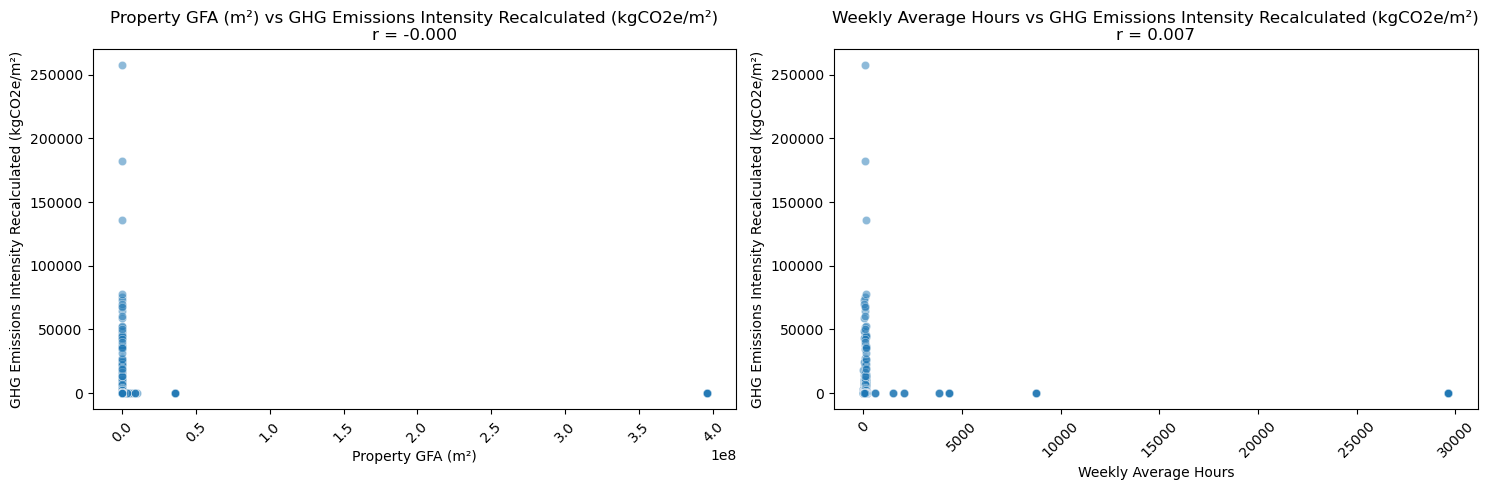

{'Property GFA (m²)': -0.00041874517997733863,
 'Weekly Average Hours': 0.006680689879337994}

In [102]:
#are there any correlations for Emission Intensity?
analyze_numerical_correlations(ontario_emissions_df,'GHG Emissions Intensity Recalculated (kgCO2e/m²)')


NUMERICAL CORRELATION ANALYSIS: GHG Emissions (1000 KG CO2e)

Correlation with Property GFA (m²): 0.004

Correlation with Weekly Average Hours: 0.012


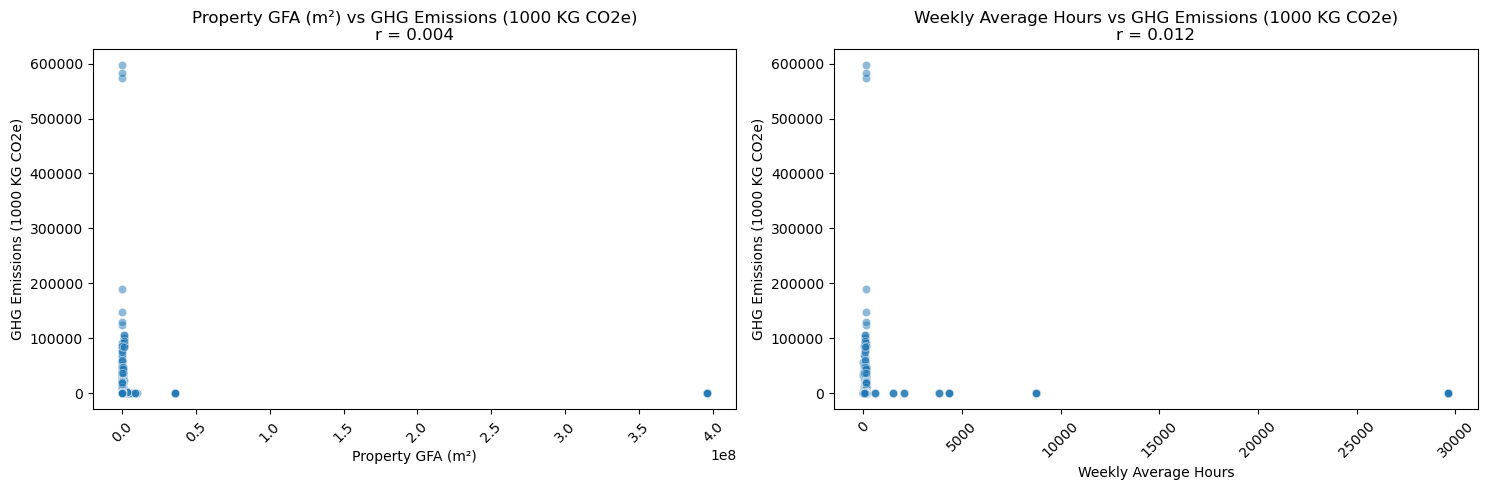

{'Property GFA (m²)': 0.0036255901273024873,
 'Weekly Average Hours': 0.012167142432131432}

In [103]:
#are there any correlations for total emissions?
analyze_numerical_correlations(ontario_emissions_df,'GHG Emissions (1000 KG CO2e)')


NUMERICAL CORRELATION ANALYSIS: Source EUI (GJ/m²)

Correlation with Property GFA (m²): -0.000

Correlation with Weekly Average Hours: -0.001


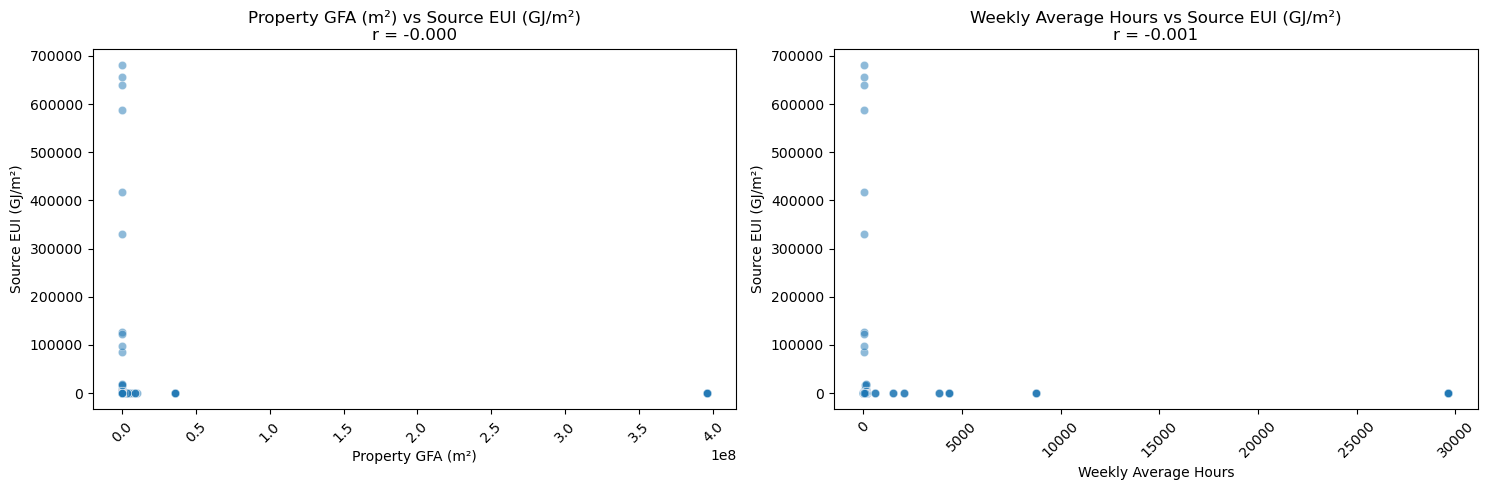

{'Property GFA (m²)': -5.3862821782097815e-05,
 'Weekly Average Hours': -0.0008596504845691544}

In [104]:
#are there any correlations for Source EUI?
analyze_numerical_correlations(ontario_emissions_df,'Source EUI (GJ/m²)')

**It's clear that size and operating hours are not correlated with any of the output variables from the prepared dataset, except for a very weak positive correlation with total emissions for both inputs.
Let's test the correlation on the dataset with the outliers removed.**


NUMERICAL CORRELATION ANALYSIS: GHG Emissions Intensity Recalculated (kgCO2e/m²)

Correlation with Property GFA (m²): -0.008

Correlation with Weekly Average Hours: 0.084


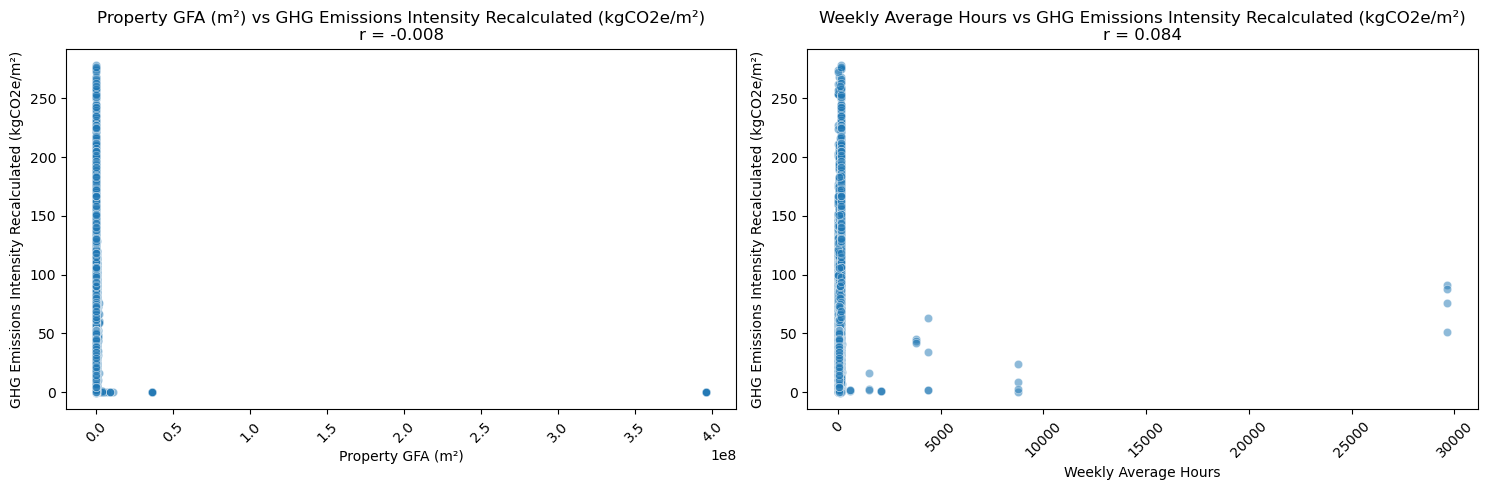

{'Property GFA (m²)': -0.008390566506054834,
 'Weekly Average Hours': 0.08404236457391184}

In [106]:
analyze_numerical_correlations(clean_data,'GHG Emissions Intensity Recalculated (kgCO2e/m²)')


NUMERICAL CORRELATION ANALYSIS: GHG Emissions (1000 KG CO2e)

Correlation with Property GFA (m²): 0.008

Correlation with Weekly Average Hours: 0.020


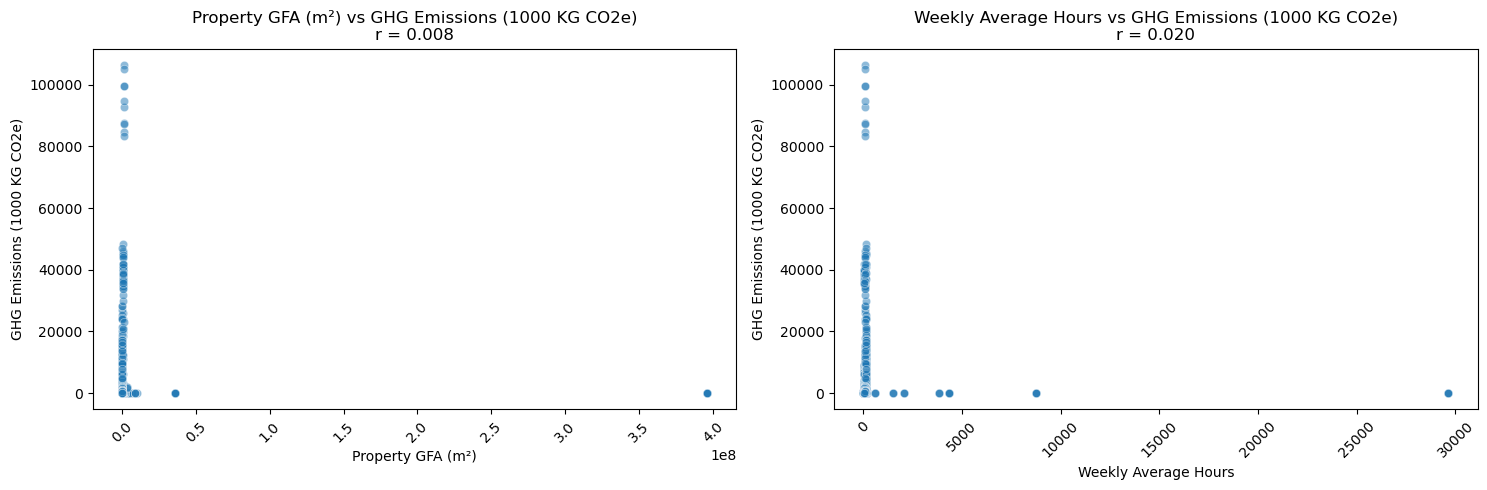

{'Property GFA (m²)': 0.007657852133122401,
 'Weekly Average Hours': 0.01986596521808675}

In [107]:
analyze_numerical_correlations(clean_data,'GHG Emissions (1000 KG CO2e)')


NUMERICAL CORRELATION ANALYSIS: Source EUI (GJ/m²)

Correlation with Property GFA (m²): -0.000

Correlation with Weekly Average Hours: -0.001


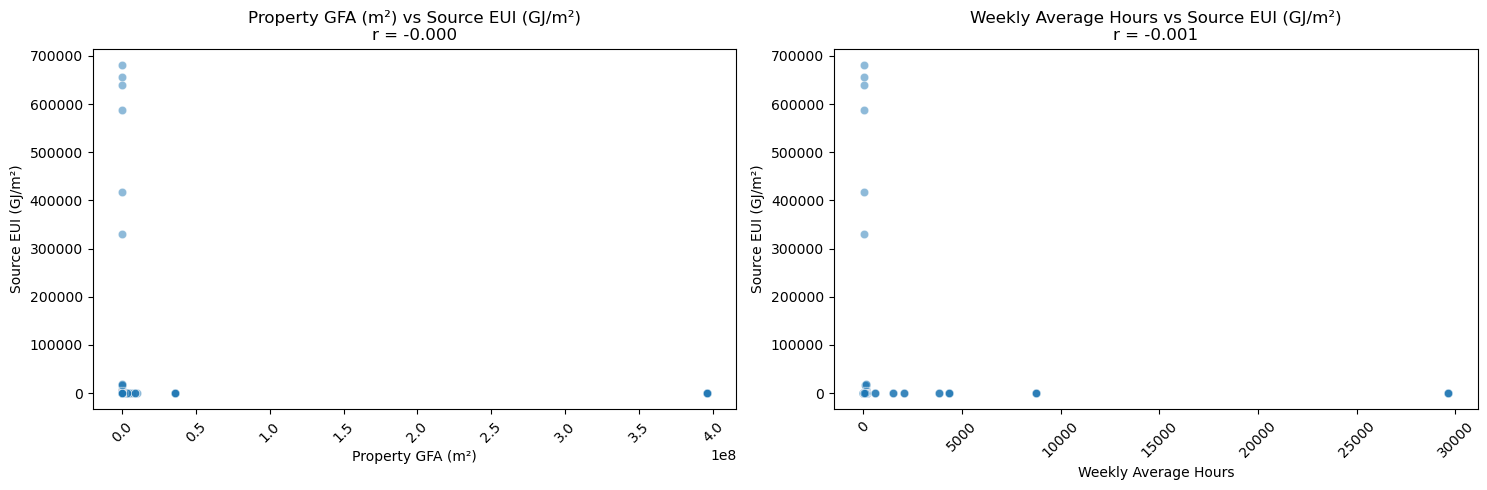

{'Property GFA (m²)': -4.688565511869988e-05,
 'Weekly Average Hours': -0.0009564197612659375}

In [108]:
analyze_numerical_correlations(clean_data,'Source EUI (GJ/m²)')

**We see some slightly stronger correlations for the total emissions and intensity, however they are still very weak so clearly the size and operating hours are not driving any results. This is a bit of a surprise, so it's possible that there are a lot of errors in the user inputs.
Since we got minimal insight from that, let's take a look at categorical input variables.**

In [110]:
#define a function to analyze categorical input relationships and understand which factors are driving results.
#Note the names of the categorical variables to assess are part of the function so need to be accurate.
def analyze_categorical_relationships(data, metric_name):
    categorical_inputs = ['Sector', 'Subsector', 'Organization', 'Operation Type', 'City', 'Postal Code']
    
    print(f"\nCATEGORICAL ANALYSIS: {metric_name}")
    print("=" * 80)
    
    # Dictionary to store ANOVA p-values
    anova_p_values = {}
    categorical_analysis_results = {}
    
    # First pass: collect p-values
    for cat_var in categorical_inputs:
        groups = [group for _, group in data.groupby(cat_var)[metric_name]]
        if len(groups) > 1:
            f_stat, p_val = stats.f_oneway(*groups)
            anova_p_values[cat_var] = round(p_val, 4)
    
    # Print summary of p-values
    print("\nSUMMARY OF ANOVA P-VALUES")
    print("-" * 80)
    for cat_var, p_val in anova_p_values.items():
        print(f"{cat_var}: {p_val}")
    
    # Second pass: perform detailed analysis
    for cat_var in categorical_inputs:
        # Calculate group statistics with rounded values
        group_stats = data.groupby(cat_var)[metric_name].agg(['count', 'mean', 'std']).round(2)
        
        # Sort by mean value
        group_stats = group_stats.sort_values('mean', ascending=False)
        
        # Perform ANOVA
        groups = [group for _, group in data.groupby(cat_var)[metric_name]]
        if len(groups) > 1:
            f_stat, p_val = stats.f_oneway(*groups)
            
            print(f"\n{cat_var} Analysis:")
            print(f"Number of categories: {len(group_stats)}")
            print(f"ANOVA p-value: {round(p_val, 4)}")
            
            print(f"\nTop 10 {cat_var} categories by mean value:")
            print("-" * 40)
            print(group_stats.head(10).to_string(float_format=lambda x: '{:.2f}'.format(x)))
            
            print(f"\nBottom 10 {cat_var} categories by mean value:")
            print("-" * 40)
            print(group_stats.tail(10).to_string(float_format=lambda x: '{:.2f}'.format(x)))
            
            # Store results
            categorical_analysis_results[cat_var] = {'stats': group_stats, 'anova_p_value': round(p_val, 4)}
            
            # Box plot
            plt.figure(figsize=(12, 6))
            sns.boxplot(data=data, x=cat_var, y=metric_name)
            plt.xticks(rotation=45, ha='right')
            plt.title(f"{metric_name} Distribution by {cat_var}")
            plt.tight_layout()
            plt.show()
    
    return categorical_analysis_results


CATEGORICAL ANALYSIS: Normalized GHG Emissions Intensity (kgCO2e/m²hr)

SUMMARY OF ANOVA P-VALUES
--------------------------------------------------------------------------------
Sector: 0.0
Subsector: 0.0
Organization: 0.0
Operation Type: 0.0
City: 0.0
Postal Code: 1.0

Sector Analysis:
Number of categories: 6
ANOVA p-value: 0.0

Top 10 Sector categories by mean value:
----------------------------------------
                  count  mean    std
Sector                              
hospital            418 34.93 696.44
public hospital    4243 23.16 515.21
municipal        106946  3.44 113.55
school board      59426  0.92  43.93
post-secondary     7438  0.72   3.23
non-bps              84  0.67   0.76

Bottom 10 Sector categories by mean value:
----------------------------------------
                  count  mean    std
Sector                              
hospital            418 34.93 696.44
public hospital    4243 23.16 515.21
municipal        106946  3.44 113.55
school board      5

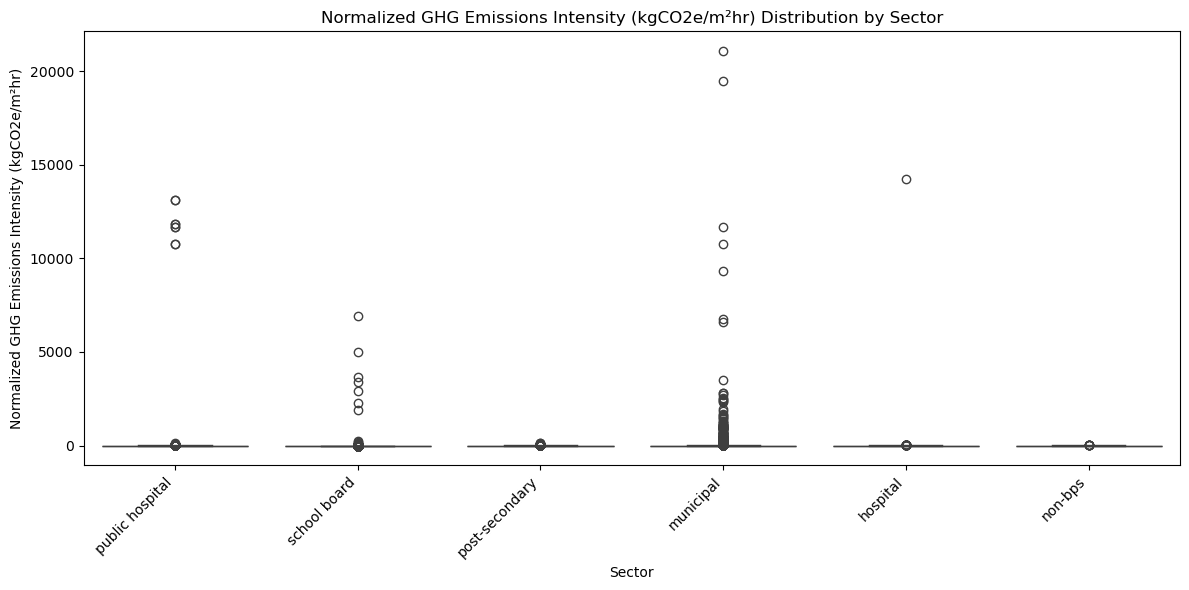


Subsector Analysis:
Number of categories: 15
ANOVA p-value: 0.0

Top 10 Subsector categories by mean value:
----------------------------------------
                          count  mean    std
Subsector                                   
acute/chronic hospital     2441 45.52 737.18
township                     17  4.09   6.10
municipality             106653  3.44 113.71
municipal                     4  2.04   2.40
school board              49707  1.01  48.04
acute/chronic              1290  0.83   0.82
municipal service board     271  0.77   1.11
university                 2690  0.76   4.90
acute hospital              377  0.72   0.93
chronic                     130  0.72   0.68

Bottom 10 Subsector categories by mean value:
----------------------------------------
                         count  mean  std
Subsector                                
acute/chronic             1290  0.83 0.82
municipal service board    271  0.77 1.11
university                2690  0.76 4.90
acute hospit

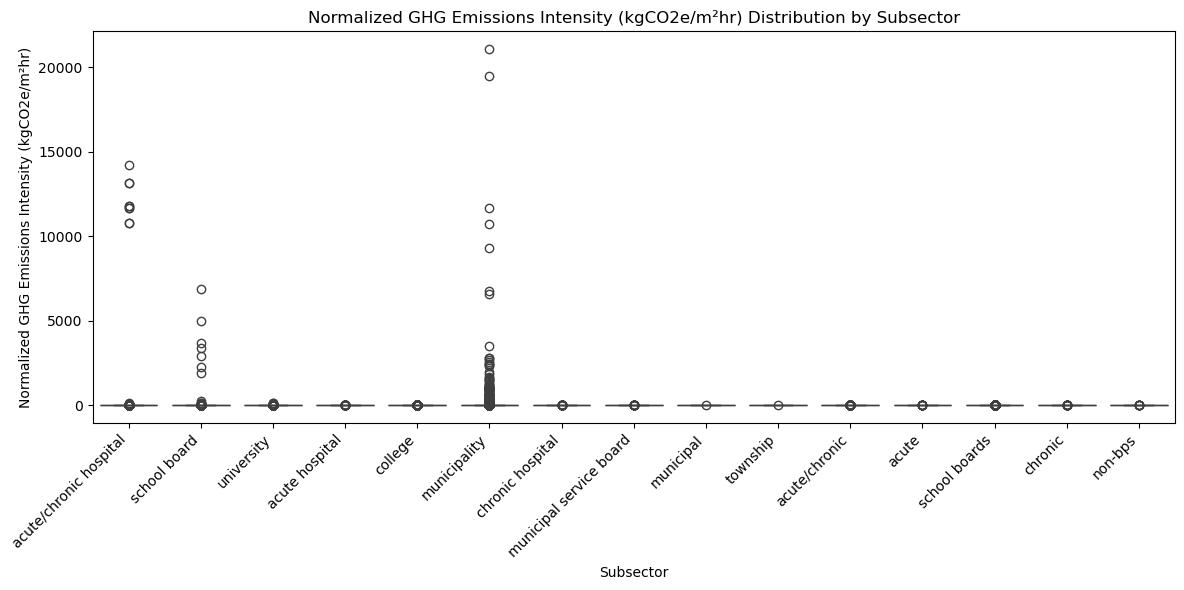


Organization Analysis:
Number of categories: 771
ANOVA p-value: 0.0

Top 10 Organization categories by mean value:
----------------------------------------
                                   count    mean     std
Organization                                            
New Liskeard Temiskaming Hospital     24 4543.12 6027.63
Township of Puslinch                  85  256.64 2285.40
Municipality of Greenstone           263  181.30 1210.72
City of Orillia                      291   98.91 1211.48
Township of Johnson                   42   68.47  288.01
Town of Grimsby                      139   68.04  386.23
Municipality of Huron Shores         140   58.53  237.30
Township of Emo                       63   56.15  174.82
Municipality of Temagami             126   51.93  269.08
Township of James                     78   51.35  132.99

Bottom 10 Organization categories by mean value:
----------------------------------------
                                                           count  me

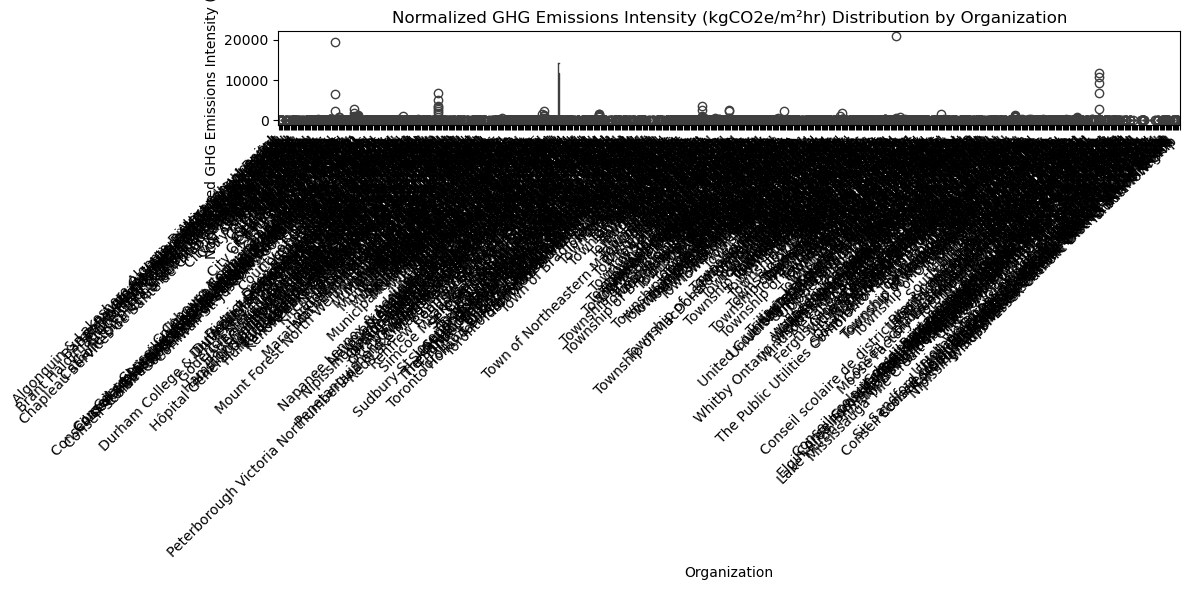


Operation Type Analysis:
Number of categories: 85
ANOVA p-value: 0.0

Top 10 Operation Type categories by mean value:
----------------------------------------
                                                                                   count   mean     std
Operation Type                                                                                         
other                                                                                131 834.17 3088.26
facilities related to the treatment of sewage                                        312  66.42 1102.00
other - streetlights                                                                 556  15.75  160.75
indoor recreational facilities                                                      1620  15.04  523.76
storage facilities where equipment or vehicles are maintained, repaired or stored   9039   8.87  223.87
other - pools                                                                       1292   5.28   29.40
convenie

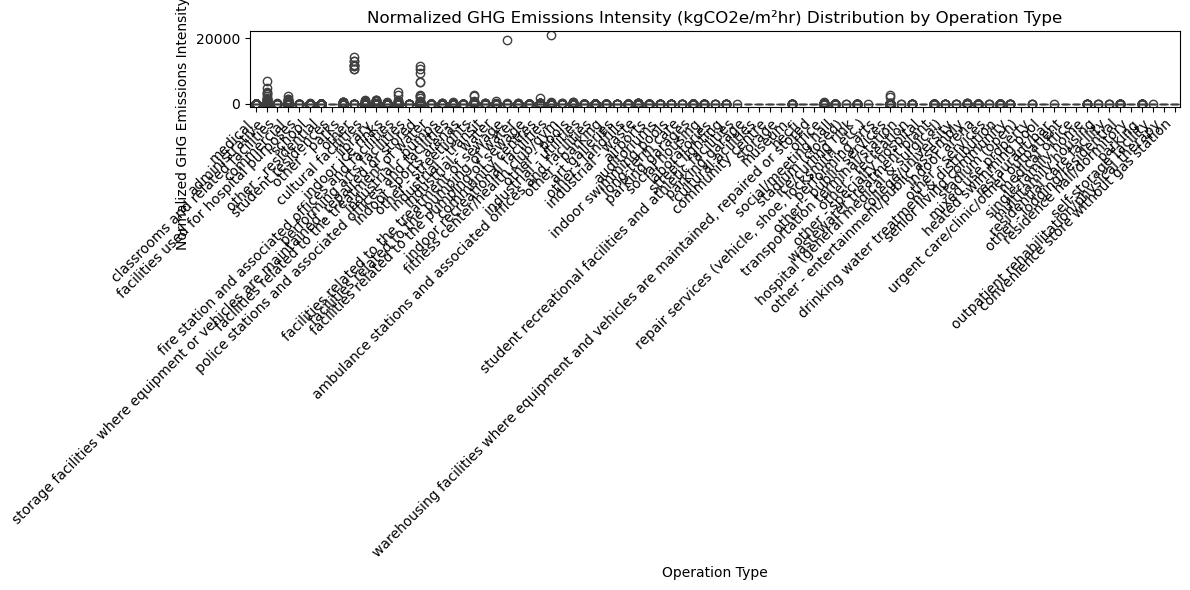


City Analysis:
Number of categories: 1526
ANOVA p-value: 0.0

Top 10 City categories by mean value:
----------------------------------------
                count   mean     std
City                                
Geraldton Ward     81 542.26 2146.12
New Liskeard      453 244.29 1698.56
Iron Bridge        86  94.81  297.72
Crediton           28  67.38  318.81
Rosseau             8  56.95   22.79
Waverley           10  51.67   81.31
Holtyre            13  51.40   20.06
Elk lake           78  51.35  132.99
Orillia           580  49.89  858.80
Temagami          138  47.47  257.44

Bottom 10 City categories by mean value:
----------------------------------------
                count  mean  std
City                            
Grey Highlands      9  0.00 0.00
STOUFFVILLE         5  0.00 0.00
0                   2  0.00 0.00
Oro-Medonte         1  0.00  NaN
Lyndhurst           2  0.00 0.00
Queenston           1  0.00  NaN
Sebright            5  0.00 0.00
Washington          3  0.00 0.00
C

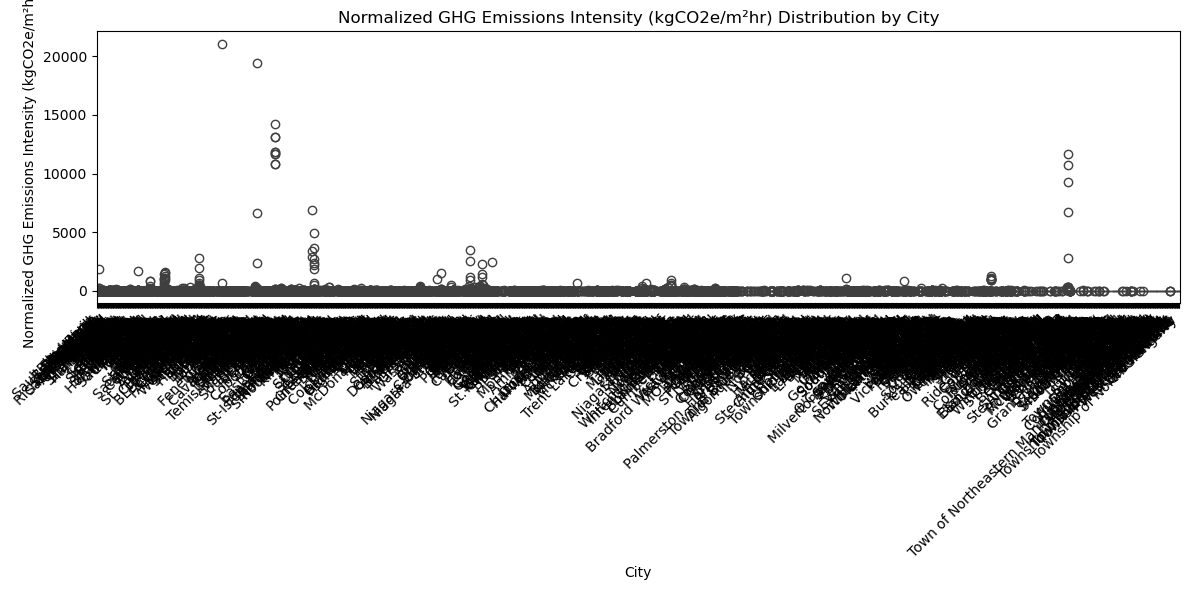


Postal Code Analysis:
Number of categories: 11296
ANOVA p-value: 1.0

Top 10 Postal Code categories by mean value:
----------------------------------------
             count    mean     std
Postal Code                       
L6J2L2           1 4981.03     NaN
L0P1E0           4 3305.28 2830.93
M4S3C4           2  997.03  113.51
L3V6Y3          10  903.54 2143.63
L3V6Z9          23  847.04 4058.95
L6J5H2           6  621.81 1488.09
L3M4E7          25  373.13  859.96
M5T2S3           4  357.28  139.27
P0T1M0         129  340.83 1716.87
L6T4B9          22  297.60  573.60

Bottom 10 Postal Code categories by mean value:
----------------------------------------
             count  mean  std
Postal Code                  
M4J3A6           4  0.00 0.00
M6P2A2           7  0.00 0.00
L1J8R6           1  0.00  NaN
M4J2Z5           2  0.00 0.00
N6J2A1           5  0.00 0.00
N6J1J6          11  0.00 0.00
M4J1N4           3  0.00 0.00
L7M4G1           4  0.00 0.00
M4H1G8           3  0.00 0.00
M4K

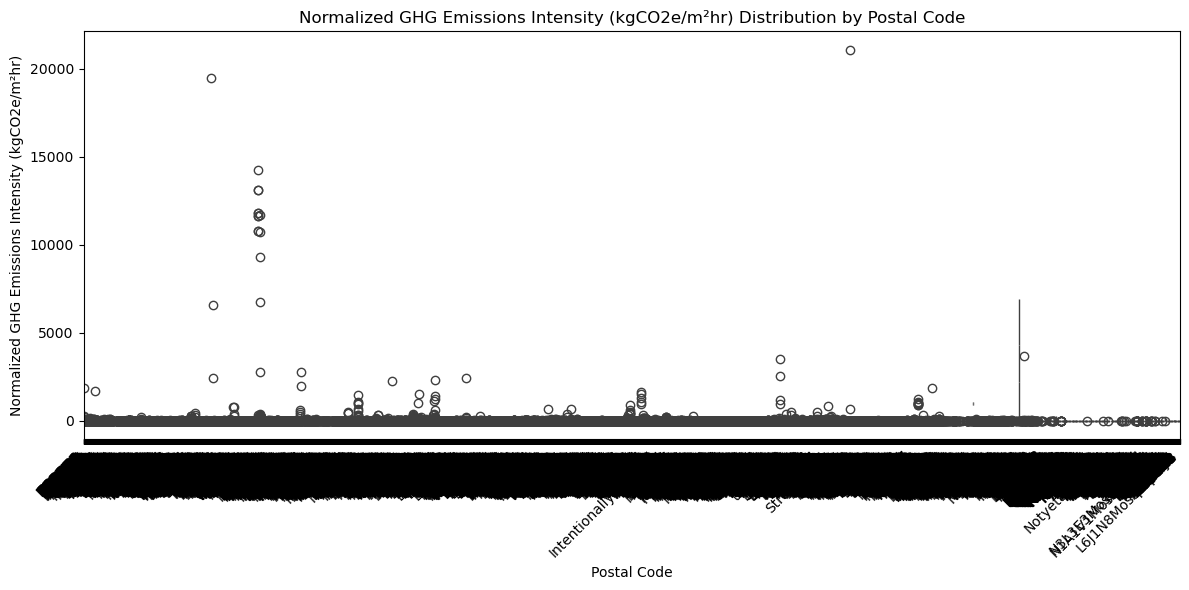

In [111]:
analyze_categorical_relationships(ontario_emissions_df,'Normalized GHG Emissions Intensity (kgCO2e/m²hr)');

The ANOVA p-values tell us that every categorical variable except Postal Code has a significant relationship with emissions intensity. Let's do some further analysis to see if we can better understand what is driving results.

# Deltas for emission totals and emissions intensities

    Year Operation_Sector  GHG Emissions (1000 KG CO2e)  Percent Change
0   2011       commercial                     506474.65            0.00
6   2012       commercial                     477469.41           -5.73
12  2013       commercial                     472380.00           -1.07
18  2014       commercial                     457508.91           -3.15
24  2015       commercial                     436629.16           -4.56


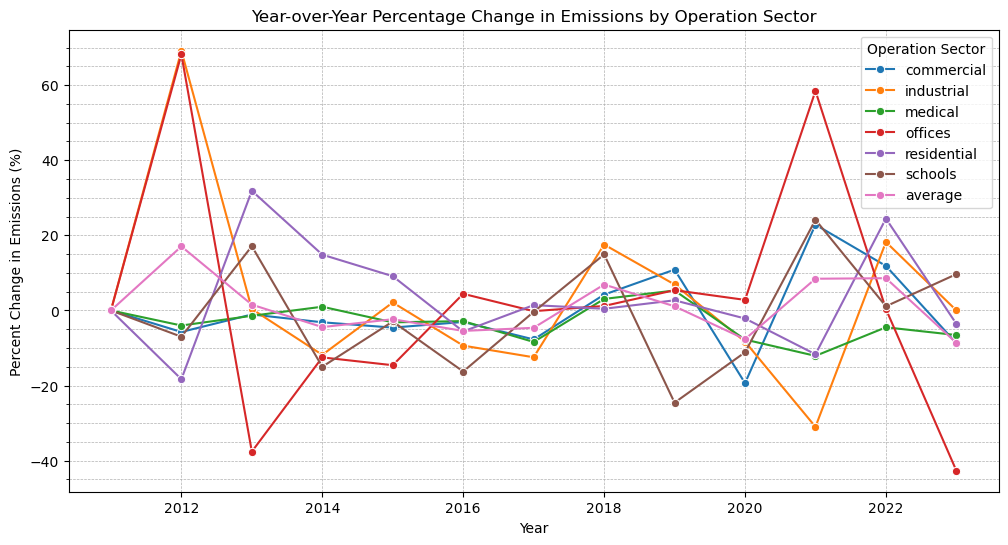

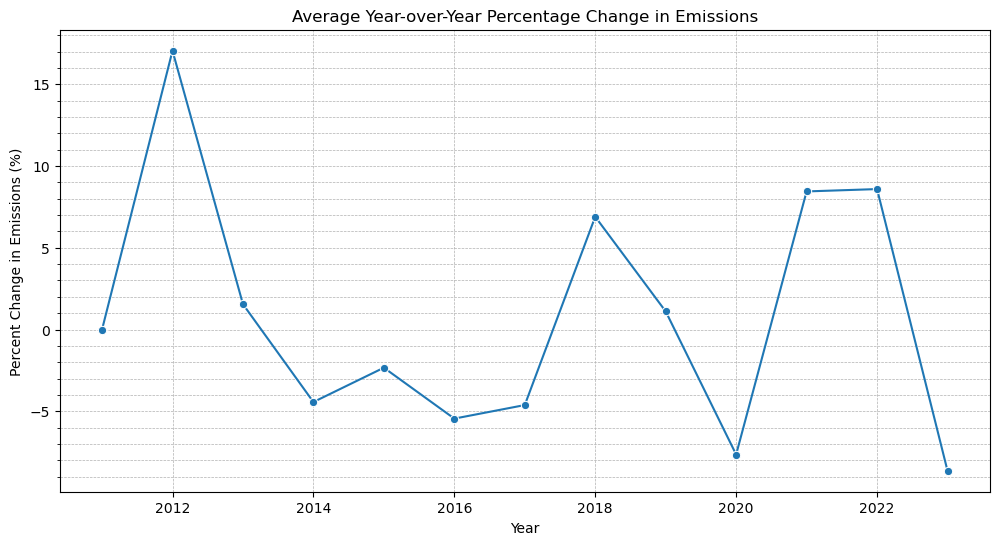

In [115]:
# Percent change of emissions year-over-year by operation sector
import matplotlib.ticker as ticker # to add minor tick marks on Y axis

grouped_year_os = ontario_emissions_df.groupby(['Year', 'Operation_Sector']) 
sums_by_year_and_os = grouped_year_os[['GHG Emissions (1000 KG CO2e)']].sum().reset_index() 
delta = [] 

for sector in sums_by_year_and_os['Operation_Sector'].unique(): 
    sector_delta = sums_by_year_and_os[sums_by_year_and_os['Operation_Sector'] == sector] 
    sector_delta = sector_delta.sort_values('Year') 
    sector_delta['Percent Change'] = sector_delta['GHG Emissions (1000 KG CO2e)'].pct_change() * 100 
    delta.append(sector_delta) 

# Concatinating dfs
delta_data = pd.concat(delta) 
delta_data.fillna(0, inplace = True)
print(delta_data.head()) 

# Calculating average delta across all sectors
avg_delta = delta_data.groupby('Year')['Percent Change'].mean().reset_index()
avg_delta['Operation_Sector'] = 'average'
concat_delta = pd.concat([delta_data, avg_delta])

# Plotting the delta of all operation sectors and the average
plt1 = plt.figure(figsize = (12, 6)) 
plt1 = sns.lineplot(data = concat_delta, x ='Year', y ='Percent Change', hue ='Operation_Sector', marker ='o') 
plt1 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt1 = plt.title('Year-over-Year Percentage Change in Emissions by Operation Sector') 
plt1 = plt.xlabel('Year') 
plt1 = plt.ylabel('Percent Change in Emissions (%)') 
plt1 = plt.legend(title = 'Operation Sector') 
plt1 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt1)

# Plotting average delta independently
plt2 = plt.figure(figsize = (12, 6)) 
plt2 = sns.lineplot(data = avg_delta, x ='Year', y ='Percent Change', marker ='o') 
plt2 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt2 = plt.title('Average Year-over-Year Percentage Change in Emissions') 
plt2 = plt.xlabel('Year') 
plt2 = plt.ylabel('Percent Change in Emissions (%)') 
plt2 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt2)


The analysis indicates that average emissions across the broader public sector decreased by 18.86% in 2023 from 2011. While this finding was significant and indicative of generalized progress, the year-over-year emission reduction findings demonstrated significant volatility across all Operation Sectors, notably in 2012. The most significant decarbonization occurred in the medical (-35.27%), school (-20.49%), offices (-18.21), and commercial (-9.85%) Operation Sectors, while industrial (14.13%) and residential (38.36%) Operation Sectors experienced significant increases.

In [117]:
# Calculating emissions delta per operation sector from 2011 to 2023
baseline_delta = ontario_emissions_df[ontario_emissions_df['Year'].isin([2011, 2023])]
annual_data = baseline_delta.groupby(['Operation_Sector','Year'])['GHG Emissions (1000 KG CO2e)'].sum().unstack()
annual_data['Percent Change'] = ((annual_data[2023] - annual_data[2011]) / annual_data[2011]) * 100

# Calculating average emissions delta for all operations sectors from 2011 to 2023
total_2011 = baseline_delta[baseline_delta['Year'] == 2011]['GHG Emissions (1000 KG CO2e)'].sum()
total_2023 = baseline_delta[baseline_delta['Year'] == 2023]['GHG Emissions (1000 KG CO2e)'].sum()
avg_delta_bl = ((total_2023 - total_2011) / total_2011) * 100

# Concatinating dfs
average_bl = pd.DataFrame({
    'Operation_Sector': ['average'], 
    2011: [total_2011], 
    2023: [total_2023], 
    'Percent Change': [avg_delta_bl]
})
annual_data.reset_index(inplace = True)
delta_bl = pd.concat([annual_data, average_bl])
delta_bl

,Operation_Sector,2011,2023,Percent Change
0,commercial,506474.65,456600.50,-9.85
1,industrial,140986.77,160914.50,14.13
2,medical,699100.36,452561.50,-35.27
3,offices,976448.57,798589.80,-18.21
4,residential,44549.90,61640.90,38.36
5,schools,566281.20,450229.30,-20.49
0,average,2933841.45,2380536.50,-18.86


    Year Operation_Sector  GHG Emissions (1000 KG CO2e)  Percent Change
0   2011       commercial                     506474.65            0.00
6   2012       commercial                     477469.41           -5.73
12  2013       commercial                     472380.00           -1.07
18  2014       commercial                     457508.91           -3.15
24  2015       commercial                     436629.16           -4.56


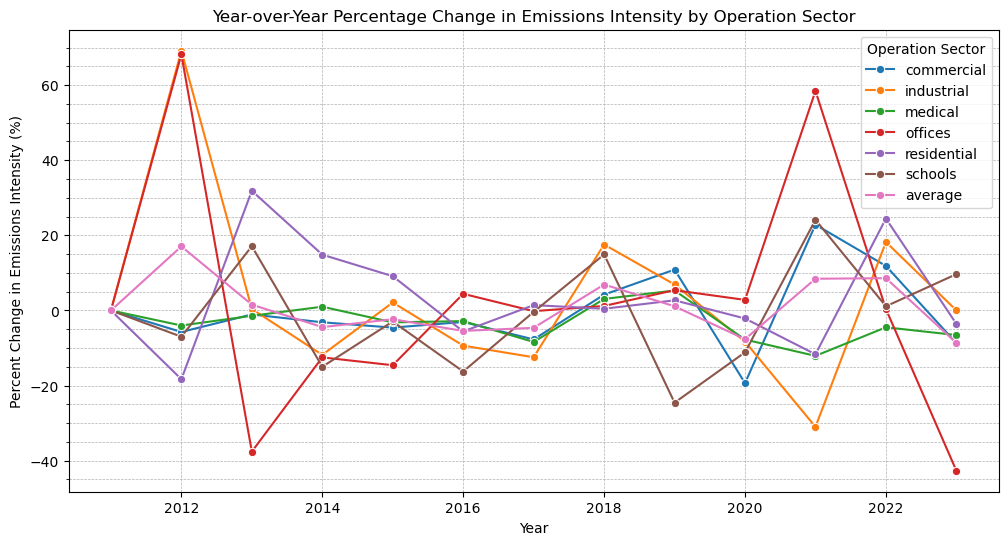

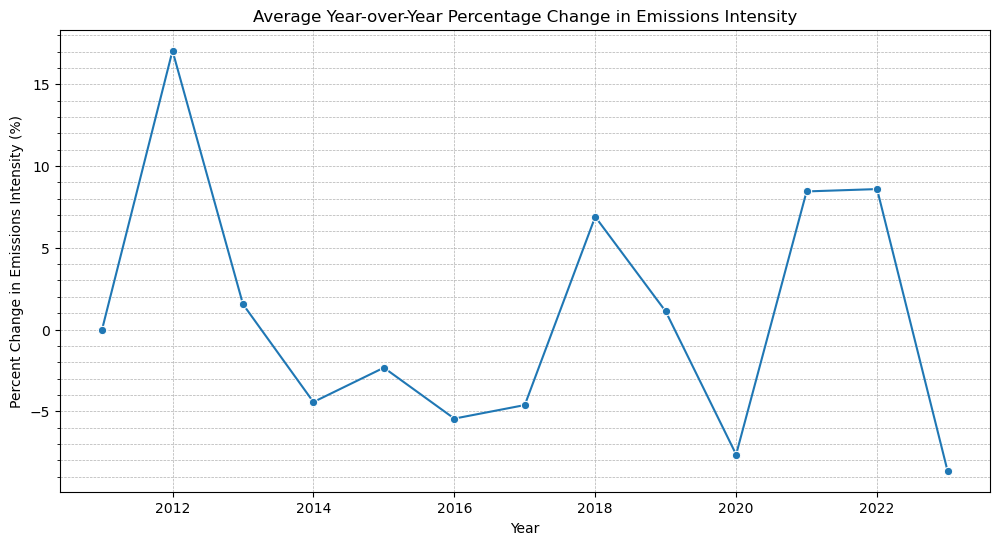

In [118]:
# Percent change for emissions intensity by Operation Sector
grouped_year_os1 = ontario_emissions_df.groupby(['Year', 'Operation_Sector']) 
sums_by_year_and_os1 = grouped_year_os['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].sum().reset_index() 
delta1 = [] 

for sector in sums_by_year_and_os1['Operation_Sector'].unique(): 
    sector_delta1 = sums_by_year_and_os1[sums_by_year_and_os1['Operation_Sector'] == sector] 
    sector_delta1 = sector_delta1.sort_values('Year') 
    sector_delta1['Percent Change'] = sector_delta1['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].pct_change() * 100 
    delta1.append(sector_delta1) 

delta_intens = pd.concat(delta) 
delta_intens.fillna(0, inplace = True)
print(delta_intens.head()) 

# Calculating average delta across all sectors
avg_delta1 = delta_intens.groupby('Year')['Percent Change'].mean().reset_index()
avg_delta1['Operation_Sector'] = 'average'
concat_delta1 = pd.concat([delta_intens, avg_delta1])

# Plotting the delta of all operation sectors and the average
plt1 = plt.figure(figsize = (12, 6)) 
plt1 = sns.lineplot(data = concat_delta1, x ='Year', y ='Percent Change', hue ='Operation_Sector', marker ='o') 
plt1 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt1 = plt.title('Year-over-Year Percentage Change in Emissions Intensity by Operation Sector') 
plt1 = plt.xlabel('Year') 
plt1 = plt.ylabel('Percent Change in Emissions Intensity (%)') 
plt1 = plt.legend(title = 'Operation Sector') 
plt1 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt1)

# Plotting average delta independently
plt2 = plt.figure(figsize = (12, 6)) 
plt2 = sns.lineplot(data = avg_delta1, x ='Year', y ='Percent Change', marker ='o') 
plt2 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt2 = plt.title('Average Year-over-Year Percentage Change in Emissions Intensity') 
plt2 = plt.xlabel('Year') 
plt2 = plt.ylabel('Percent Change in Emissions Intensity (%)') 
plt2 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt2)

In [119]:
# Calculating emissions delta per operation sector from 2011 to 2023
baseline_intens = ontario_emissions_df[ontario_emissions_df['Year'].isin([2011, 2023])]
annual_intens = baseline_intens.groupby(['Operation_Sector','Year'])['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].sum().unstack()
annual_intens['Percent Change'] = ((annual_intens[2023] - annual_intens[2011]) / annual_intens[2011]) * 100

# Calculating average emissions delta for all operations sectors from 2011 to 2023
Total_2011 = baseline_intens[baseline_intens['Year'] == 2011]['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].sum()
Total_2023 = baseline_intens[baseline_intens['Year'] == 2023]['GHG Emissions Intensity Recalculated (kgCO2e/m²)'].sum()
avg_intens_bl = ((total_2023 - total_2011) / total_2011) * 100

# Concatinating dfs
average_intens = pd.DataFrame({
    'Operation_Sector': ['average'], 
    2011: [Total_2011], 
    2023: [Total_2023], 
    'Percent Change': [avg_intens_bl]
})
annual_intens.reset_index(inplace = True)
intens_bl = pd.concat([annual_intens, average_intens])
intens_bl

,Operation_Sector,2011,2023,Percent Change
0,commercial,284946.56,637601.92,123.76
1,industrial,341733.30,106301.38,-68.89
2,medical,110070.02,43544.73,-60.44
3,offices,94737.54,130081.38,37.31
4,residential,10440.60,22710.37,117.52
5,schools,49090.97,16757.10,-65.87
0,average,891018.99,956996.88,-18.86


    Year Operation_Sector  Normalized GHG Emissions Intensity (kgCO2e/m²hr)  \
0   2011       commercial                                          31994.46   
6   2012       commercial                                          13954.96   
12  2013       commercial                                          12890.74   
18  2014       commercial                                          11638.13   
24  2015       commercial                                          10452.01   

    Percent Change  
0             0.00  
6           -56.38  
12           -7.63  
18           -9.72  
24          -10.19  


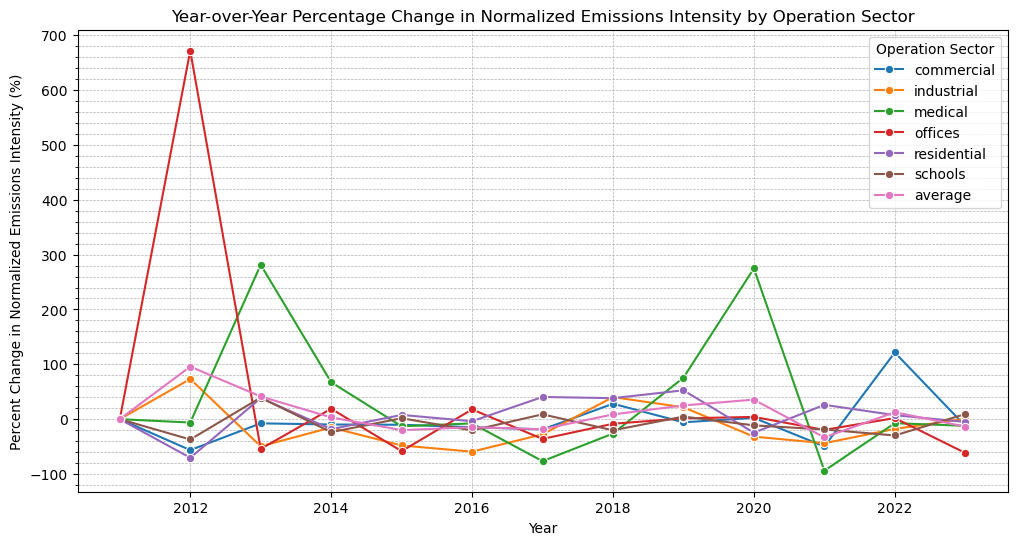

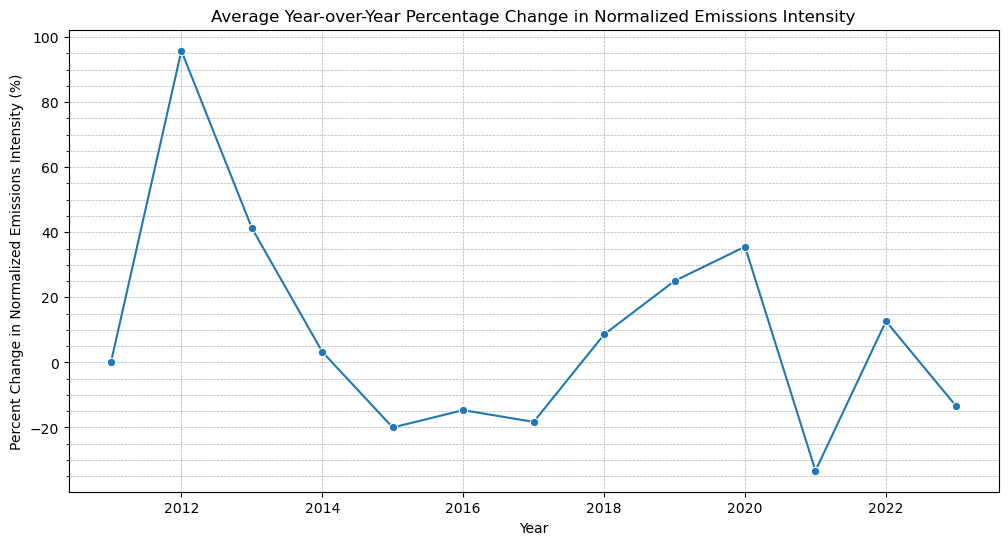

In [120]:
# Percent change for normalized emissions intensity by Operation Sector
grouped_year_os2 = ontario_emissions_df.groupby(['Year', 'Operation_Sector']) 
sums_by_year_and_os2 = grouped_year_os['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].sum().reset_index() 
delta2 = [] 

for sector in sums_by_year_and_os2['Operation_Sector'].unique(): 
    sector_delta2 = sums_by_year_and_os2[sums_by_year_and_os2['Operation_Sector'] == sector] 
    sector_delta2 = sector_delta2.sort_values('Year') 
    sector_delta2['Percent Change'] = sector_delta2['Normalized GHG Emissions Intensity (kgCO2e/m²hr)'].pct_change() * 100 
    delta2.append(sector_delta2) 

delta_intens1 = pd.concat(delta2) 
delta_intens1.fillna(0, inplace = True)
print(delta_intens1.head()) 

# Calculating average delta across all sectors
avg_delta2 = delta_intens1.groupby('Year')['Percent Change'].mean().reset_index()
avg_delta2['Operation_Sector'] = 'average'
concat_delta2 = pd.concat([delta_intens1, avg_delta2])

# Plotting the delta of all operation sectors and the average
plt1 = plt.figure(figsize = (12, 6)) 
plt1 = sns.lineplot(data = concat_delta2, x ='Year', y ='Percent Change', hue ='Operation_Sector', marker ='o') 
plt1 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt1 = plt.title('Year-over-Year Percentage Change in Normalized Emissions Intensity by Operation Sector') 
plt1 = plt.xlabel('Year') 
plt1 = plt.ylabel('Percent Change in Normalized Emissions Intensity (%)') 
plt1 = plt.legend(title = 'Operation Sector') 
plt1 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt1)

# Plotting average delta independently
plt2 = plt.figure(figsize = (12, 6)) 
plt2 = sns.lineplot(data = avg_delta2, x ='Year', y ='Percent Change', marker ='o') 
plt2 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt2 = plt.title('Average Year-over-Year Percentage Change in Normalized Emissions Intensity') 
plt2 = plt.xlabel('Year') 
plt2 = plt.ylabel('Percent Change in Normalized Emissions Intensity (%)') 
plt2 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt2)

The high-level analysis of Emissions Intensity Recalculated deltas suggest that emissions intensity deltas for the commercial Operation Sector had also fallen on average from 2011 to 2023. However, average intensity varies dramatically across Operation Sectors, ranging from an increase of 123.76% in the commercial Operation Sector to a 68.89% decrease in the industrial Operation Sector. 

However, the Normalized GHG Emissions Intensity (kg CO2e/m²hr) data revealed a downward trend in the mean values, standard deviations, and maximum values of this data over the years. This indicates that a significant shift in the data occurred somewhere between 2014 and 2017. The years 2011 to 2014 exhibit higher variability (indicated by larger standard deviations) compared to the later years. The lower and upper quartiles (25% and 75%) generally show a downward trend along with the mean.

It is highly likely that a fundamental change occurred in the underlying phenomenon being measured around 2017. This could be due to a range of factors, including market saturation, technological advancements, economic factors, regulatory changes, to name a few. The higher variability in earlier years could be attributed to less mature data collection processes, reporting errors, or a more dynamic environment during that period.

The results suggest that the commercial and industrial Operation Sectors have relatively high standard deviations, indicating greater variability in their data. This suggests that factors influencing the measured variable might have a stronger or more diverse impact in these Operation Sectors.

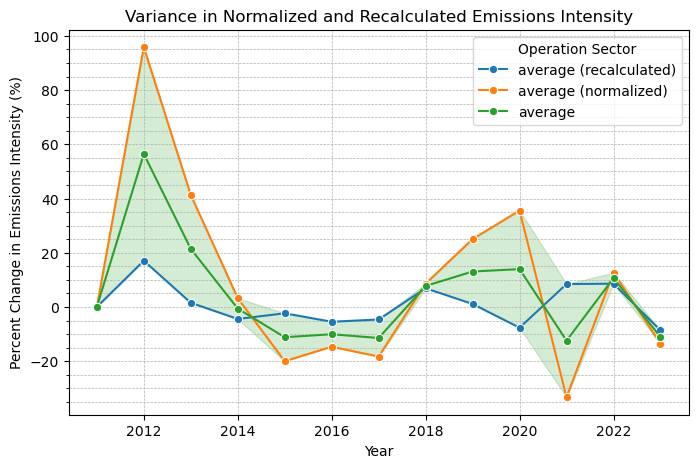

In [122]:
#Visualizing normalized and recalculated emissions intensities

avg_recalc = avg_delta1
avg_recalc['Operation_Sector'] = 'average (recalculated)'

avg_norm = avg_delta2
avg_norm['Operation_Sector'] = 'average (normalized)'

avg_comb = pd.concat([avg_delta1, avg_delta2])
avg_comb['Operation_Sector'] = 'average'

compare = pd.concat([avg_recalc, avg_norm, avg_comb])

plt1 = plt.figure(figsize = (8, 5)) 
plt1 = sns.lineplot(data = compare, x ='Year', y ='Percent Change', hue ='Operation_Sector', marker ='o') 
plt1 = plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator()) # Setting minor ticks on y-axis 
plt1 = plt.title('Variance in Normalized and Recalculated Emissions Intensity') 
plt1 = plt.xlabel('Year') 
plt1 = plt.ylabel('Percent Change in Emissions Intensity (%)') 
plt1 = plt.legend(title = 'Operation Sector') 
plt1 = plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5) # Enabling grid for both major and minor ticks
plt.show(plt1)

# Linear Regression Model

The response variable of interest, greenhouse gas emissions, is expressed as a continuous variable. As such, we will build a linear regression model to describe the linear relationship between a couple of the key predictor variables in the dataset and the GHG emissions response.

Two different model building processes will be addressed using two different response variables:

Model option #1: 
- Response variable is GHG Emissions Intensity Recalculated (kgCO2e/m²)

Model option #2:
- Response variable is Normalized GHG Emissions Intensity (kgCO2e/m²/hr) which will build in the operating hours

The response variable will also need to be log transformed given the wide range of results across sectors

The following predictor variables will be incorporated into the model:
- Operation sector 
- Year

Rationale and approach for predictors:
- Operation sector, particularly industrial sector, is the primary predictor of interest. This variable has 6 categories which will be transformed into dummy variables for independent evaluation of effect of each sector on emissions. 
- As outlined above, there is a general decline in emissions over the period covered by the data so this will likely be an important influencer on the model.

First the `sector` variable needs to be reclassified as categorical and reordered so that we can use the industrial category as the reference as outlined in our analysis plan

In [126]:
ontario_emissions_df['Operation_Sector'] = ontario_emissions_df['Operation_Sector'].astype('category')

ontario_emissions_df['Operation_Sector']

0         medical
1         offices
2         offices
3         offices
4         offices
           ...   
178550    offices
178551    offices
178552    offices
178553    offices
178554    offices
Name: Operation_Sector, Length: 178555, dtype: category
Categories (6, object): ['commercial', 'industrial', 'medical', 'offices', 'residential', 'schools']

In [127]:
ontario_emissions_df['Operation_Sector'] = ontario_emissions_df['Operation_Sector'].cat.reorder_categories(['industrial', 'commercial', 'medical', 'offices', 'residential', 'schools'])

ontario_emissions_df['Operation_Sector']

0         medical
1         offices
2         offices
3         offices
4         offices
           ...   
178550    offices
178551    offices
178552    offices
178553    offices
178554    offices
Name: Operation_Sector, Length: 178555, dtype: category
Categories (6, object): ['industrial', 'commercial', 'medical', 'offices', 'residential', 'schools']

In [128]:
#select the variables needed and rename for ease of use in model building language

new_names = ['ghg_recalc', 'ghg_normalized', 'year', 'sector']
emissions_model_df = ontario_emissions_df[['GHG Emissions Intensity Recalculated (kgCO2e/m²)', 'Normalized GHG Emissions Intensity (kgCO2e/m²hr)', 'Year', 'Operation_Sector']]
emissions_model_df.columns = new_names

emissions_model_df.head()

,ghg_recalc,ghg_normalized,year,sector
0,100.40,0.60,2020,medical
1,37.89,0.76,2020,offices
2,17.36,0.35,2020,offices
3,46.54,0.93,2020,offices
4,26.57,0.53,2020,offices


### Model option 1: dependent variable is GHG Emissions Intensity Recalculated (kgCO2e/m²)

In [130]:
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf

#### Operating sector only

In [132]:
y, X_sector = patsy.dmatrices('ghg_recalc ~ sector', emissions_model_df)

In [133]:
model_sector = sm.OLS(y, X_sector)

In [134]:
results_sector = model_sector.fit()

print(results_sector.summary())

                            OLS Regression Results                            
Dep. Variable:             ghg_recalc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     26.14
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           1.73e-26
Time:                        22:32:06   Log-Likelihood:            -1.5015e+06
No. Observations:              178555   AIC:                         3.003e+06
Df Residuals:                  178549   BIC:                         3.003e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               125.41

In [135]:
y, X_year = patsy.dmatrices('ghg_recalc ~ year', emissions_model_df)

In [136]:
model_year = sm.OLS(y, X_year)

In [137]:
results_year = model_year.fit()

print(results_year.summary())

                            OLS Regression Results                            
Dep. Variable:             ghg_recalc   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.855
Date:                Sun, 08 Dec 2024   Prob (F-statistic):             0.0276
Time:                        22:32:06   Log-Likelihood:            -1.5015e+06
No. Observations:              178555   AIC:                         3.003e+06
Df Residuals:                  178553   BIC:                         3.003e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3125.2341   1446.962     -2.160      0.0

#### Sector and year

In [139]:
y, X_sector_year = patsy.dmatrices('ghg_recalc ~ sector + year', emissions_model_df)

In [140]:
model_sector_year = sm.OLS(y, X_sector_year)

In [141]:
results_sector_year = model_sector_year.fit()

print(results_sector_year.summary())

                            OLS Regression Results                            
Dep. Variable:             ghg_recalc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     22.40
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           1.57e-26
Time:                        22:32:07   Log-Likelihood:            -1.5015e+06
No. Observations:              178555   AIC:                         3.003e+06
Df Residuals:                  178548   BIC:                         3.003e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -2670.16

**What the results indicate:**

In the model with both sector and year, we see that for each increase of 1 year, there is a 1.58 increase in kilograms of CO2 emissions per square metre of building space. In terms of sector, we see that each sector outperforms industrial sector as anticipated: each sector has between 45 and 89 fewer kilograms of CO2 emissions per square metre of building space compared to industrial sector buildings.

The sector results are highly significant with p-values that are lower than 0.0001. The year result is not significant at the p<0.05 level and the 95% confidence interval includes the null (0 value) so we can probably reject this association. 

The adjusted r-squared value is extremely low which indicates that these variables contribute very little to explaining emissions per building space: at 0.001 it only explains 0.1% of the variance! This is likely due to the massively huge emissions values still skewing the model despite our efforts to eliminate obvious outliers. We can see the skew from the skewness value which should be close to 0 for normally distributed data but here is 133.

### Model option 2: dependent variable is Normalized GHG Emissions Intensity (kgCO2e/m2/hr)

#### Operating sector only

In [145]:
y_norm, X_sector = patsy.dmatrices('ghg_normalized ~ sector', emissions_model_df)

In [146]:
model_sector = sm.OLS(y_norm, X_sector)

In [147]:
results_sector = model_sector.fit()

print(results_sector.summary())

                            OLS Regression Results                            
Dep. Variable:         ghg_normalized   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     12.63
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           2.75e-12
Time:                        22:32:07   Log-Likelihood:            -1.1165e+06
No. Observations:              178555   AIC:                         2.233e+06
Df Residuals:                  178549   BIC:                         2.233e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.04

In [148]:
y_norm, X_year = patsy.dmatrices('ghg_normalized ~ year', emissions_model_df)

In [149]:
model_year = sm.OLS(y_norm, X_year)

In [150]:
results_year = model_year.fit()

print(results_year.summary())

                            OLS Regression Results                            
Dep. Variable:         ghg_normalized   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     17.87
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           2.36e-05
Time:                        22:32:07   Log-Likelihood:            -1.1166e+06
No. Observations:              178555   AIC:                         2.233e+06
Df Residuals:                  178553   BIC:                         2.233e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    711.2238    167.524      4.245      0.0

#### Sector and year

In [152]:
y_norm, X_sector_year = patsy.dmatrices('ghg_normalized ~ sector + year', emissions_model_df)

In [153]:
model_sector_year = sm.OLS(y_norm, X_sector_year)

In [154]:
results_sector_year = model_sector_year.fit()

print(results_sector_year.summary())

                            OLS Regression Results                            
Dep. Variable:         ghg_normalized   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     13.34
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           3.57e-15
Time:                        22:32:07   Log-Likelihood:            -1.1165e+06
No. Observations:              178555   AIC:                         2.233e+06
Df Residuals:                  178548   BIC:                         2.233e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               698.69

**What the results indicate:**

In these models that now include some controlling for operating hours, we see some differences compared to the previous set of models. 

For the model of both sector and year, we see that for each increase of 1 year, there is now a 0.35 decrease in kilograms of CO2 emissions per square metre of building space per operating hour. In terms of sector, we still see that almost all sectors outperform the industrial sector as anticipated with the exception of medical: each other sector has between 3.2 and 5.2 fewer kilograms of CO2 emissions per square metre of building space per operating hour compared to industrial sector buildings. For medical and emergency services there is actually 1.6 more kgCO2/m2/hr, although the p-value is not less than 0.05 and the 95% CI includes the null 0 value, so we can likely reject this finding.  

The other sector results are significant with p-values that are lower than 0.05. The year result is highly significant with p<0.0001. 

The adjusted r-squared value is still extremely low which indicates that these variables contribute very little to explaining emissions per building space. This is likely due to the massively huge emissions values still skewing the model despite our efforts to eliminate obvious outliers. The skewness value is still high at 107.